# Clasificación con redes neuronales

En este notebook simple usaremos una FCNN (completamente conectada) para resolver el problema de clasificación de ID de partículas, visto previamente para SVMs.

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [3]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
matplotlib.rcParams['figure.dpi'] = 300

### Librerías para Deep Learning

[Tensorflow](https://www.tensorflow.org/?hl=es-419) es una biblioteca de uso muy común para el desarrollo de modelos de aprendizaje profundo. Es una plataforma de código abierto desarrollada por Google. Admite programación en varios lenguajes, como C++, Java, Python, y muchos otros.

[Keras](https://keras.io/) es una API de alto nivel (Application Programming Interface) construida sobre TensorFlow (o Theano, otra biblioteca de aprendizaje profundo). Es específica para Python, y podemos pensar en ella como el equivalente de la biblioteca sklearn, pero para redes neuronales. Es menos general y menos personalizable, pero muy fácil de usar y comparativamente más sencilla que TensorFlow.

[PyTorch](https://pytorch.org/) es otra biblioteca muy popular para el desarrollo de modelos de aprendizaje profundo, desarrollada por Meta (Facebook). A diferencia de Keras, no es una API de alto nivel sobre otra biblioteca, sino un framework completo en sí mismo. Es especialmente popular en investigación por su flexibilidad para construir arquitecturas no estándar, aunque eso viene con una curva de aprendizaje más pronunciada y bastante más código para tareas simples.

En este curso usaremos Keras con TensorFlow como back-end, porque para los problemas que veremos su simplicidad tiene más peso que la flexibilidad extra de PyTorch.

**Comparación**

| | TensorFlow | Keras | PyTorch |
|---|---|---|---|
| **Qué es** | Framework completo | API de alto nivel (sobre TensorFlow) | Framework completo |
| **Desarrollado por** | Google | Ahora integrado a TensorFlow | Meta (Facebook) |
| **Curva de aprendizaje** | Media-alta | Baja | Media-alta |
| **Líneas de código para un modelo simple** | Muchas | Pocas | Muchas |
| **Flexibilidad para arquitecturas no estándar** | Alta | Media | Muy alta |
| **Dónde se usa más** | Producción, industria | Prototipado rápido, docencia | Investigación, papers recientes |


In [4]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [5]:
#!pip install tensorflow

In [6]:
import tensorflow as tf

In [7]:
tf.__version__

'2.20.0'

Importamos `keras` y usaremos `Sequential`, que admite una entrada y una salida

In [8]:
import keras

from keras.models import Sequential # El modelo se construye agregando una capa después de otra

from keras.layers import Dense #totalmente conectadas: cada output se conecta con cada input

from keras.layers import Dropout #para regularización

Comenzamos con el problema de 4top vs ttbar, y utilizamos la configuración en la que añadimos las características "número de leptones", "número de jets", etc. Como referencia, el SVM óptimo alcanzó un 94-95% de precisión. Cabe destacar que esos números no se obtuvieron utilizando validación cruzada anidada, por lo que podrían ser ligeramente optimistas.

In [9]:
X = pd.read_csv('/content/drive/MyDrive/Features_lim_2.csv')

In [10]:
y = np.genfromtxt('/content/drive/MyDrive/Labels_lim_2.txt')

In [11]:
X.values.shape

(5000, 24)

In [12]:
X.head()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0


In [13]:
y

array([0., 0., 0., ..., 0., 1., 0.])

Aquí no hay un proceso de validación cruzada "integrado", por lo que tendríamos que implementarlo nosotros mismos. Por ahora, podemos construir tres conjuntos: entrenamiento, validación (para la optimización de parámetros) y prueba (para la evaluación final). Idealmente, deberíamos estructurarlo como una validación cruzada.

En la práctica, rara vez se hace CV k-fold completa con redes neuronales. Cada fold implica reentrenar la red desde cero, así que el costo computacional escala rápido: con 5 folds ya estamos pagando 5 veces el costo de entrenamiento, y eso antes de siquiera empezar a buscar hiperparámetros. Además, la razón principal para usar CV es obtener una estimación confiable del desempeño cuando el dataset es chico; con datasets grandes (el escenario típico donde las NN funcionan mejor), un solo split bien hecho ya da una estimación razonablemente estable.

Por eso optamos por un split fijo train/validación/prueba, y usamos el set de validación para *early stopping* y ajuste de hiperparámetros. Esto evita el costo de CV sin sacrificar demasiado rigor.

#### Sets de entrenamiento y prueba

Este dataset tiene un desbalance importante entre las dos clases. Para que esa proporción se mantenga en cada split, usamos `stratify` al dividir los datos.

In [14]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total)))

{np.float64(0.0): np.int64(4189), np.float64(1.0): np.int64(811)}


In [15]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.19


In [16]:
# Primero separamos test (20%), estratificado por clase
X_temp, X_test, y_temp, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=10
)

# Del resto, separamos train/val (80/20 de lo que queda)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=10
)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(3200, 24) (800, 24) (1000, 24)
Balance train: 0.1621875 | val: 0.1625 | test: 0.162


### Construyendo la red

Pensemos en la arquitectura del modelo.

Nuestra capa de entrada tiene **24 neuronas** (24 características)

Nuestra capa de salida tiene **una neurona** (la salida es la probabilidad de que el objeto pertenezca a la clase positiva). También podríamos configurarla con dos neuronas (y usar softmax como la no linealidad final), pero esto es redundante en un problema de clasificación binaria. La neurona de salida será una función **sigmoide**

Añadiremos **dos capas ocultas**. En este caso, ambas tienen tamaño = 20 (debemos optimizar este hiperparámetro!). También podemos reservar la posibilidad de añadir una capa de dropout después de cada una.

Otras decisiones que debemos tomar son: qué no linealidades usar (por ahora: ReLU para las capas ocultas, sigmoide para la final), qué optimizador usar (Adam), qué tasa de aprendizaje inicial adoptar (aquí 0.001, aunque nuevamente esto debería decidirse mediante CV), el número de épocas (por ejemplo, 100; podemos graficar cantidades de interés para verificar que esto sea suficiente), el tamaño de lote (batch size) para el paso de descenso por gradiente (aquí 200, pero podemos explorarlo!) y la función de pérdida. Esta última es la entropía cruzada binaria ([binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)), que es la elección estándar para problemas de clasificación donde la salida es una probabilidad. Premia la "confianza" en una predicción correcta (alta probabilidad).

El siguiente comando nos ayuda a explorar todas las posibles opciones

In [17]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [18]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

La opción estándar para un caso como el nuestro, donde las etiquetas son 0/1, pero podemos predecir una probabilidad, es binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

$p$ es la probabilidad de que un objeto pertenezca a la clase positiva. Penaliza los ejemplos positivos que están asociados con una probabilidad predicha baja, y los ejemplos negativos que están asociados con una probabilidad predicha alta.


Acá una lista de funciones de activación

In [19]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

### Así es como construímos la red completamente conectada en Keras

In [20]:
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid'))

model.summary() # resumen de la arquitectura



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

Con el keyword `métrica` podemos cambiar a la métrica que queremos ver. El valor absoluto de la pérdida no se traduce directamente en algo intuitivo (a diferencia de accuracy, que sí es un % de aciertos), aunque sigue siendo muy útil para comparar train vs. validación y detectar overfitting.

### Ahora pruebe usted

Usando el mismo código de arriba como plantilla, modifíquelo para responder:

**¿Qué pasa si agrega una tercera capa oculta?** Agréguela (por ejemplo, de tamaño 20 también) y comenten: ¿por qué una arquitectura más profunda podría ayudar o no ayudar en este problema?

**¿Qué pasa si cambia el tamaño de las capas ocultas** (por ejemplo, de 20 a 5, o de 20 a 100)? Antes de correrlo: ¿espera que la red sea más lenta o más rápida de entrenar? ¿Más o menos propensa a sobreajustar?

**¿Qué pasa si usa otra función de activación** en las capas ocultas (por ejemplo `tanh` en vez de `relu`)? Revise la lista de activaciones disponibles que exploramos arriba con `dir(keras.activations)`.

No hace falta entrenar todavía, solo construyan el modelo con `model.summary()` al final y observe cómo cambia el número de parámetros totales según sus decisiones.


In [22]:
model2 = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model2.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model2.add(Dense(20, activation='tanh'))

# Capa adicional de prueba
model2.add(Dense(20, activation="tanh"))

# Agrega capa de salida
model2.add(Dense(1, activation='sigmoid'))


model2.summary() # resumen de la arquitectura



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

- Aumenta considerablemente el número de parámetros a ajustar. Podría ayudar a introducir más no-linealidad al modelo tal de resolver y encontrar la información relevante del dataset. De la misma forma, si la información no requiere o no tiene este grado de no-linealidad, observaríamos un sobreajuste del modelo al estar aprendiendo detalles finos que no responden a la información real del dataset sino a errores estadísticos o similares.  
- De manera similar, aumenta la complejidad de la red y con esto los parámetros a entrenar. Por esto mismo, será más lenta de entrenar y más propensa al sobreajuste por lo explicado anteriormente.  
- Se introducen otro tipo de no-linealidades y complejidad al modelo. Dependiendo del problema puede ser útil estudiar cierto tipo de función de activación que responda a características del problema que son conocidas.

### Listos para ajustar!

Nota también los hiperparámetros adicionales "epochs" (el número de pasadas completas de ida y vuelta sobre el conjunto de datos) y "batch size" (cuántos datos se utilizan en cada paso para actualizar los pesos).

### Antes de correr esto

¿Qué accuracy espera que logre esta red? Como referencia, el SVM óptimo llegó a 94-95%. Escriba su predicción antes de correr la celda de abajo.

> Mi predicción de accuracy: 92%

In [23]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7319 - loss: 7615.7964 - val_accuracy: 0.6750 - val_loss: 3535.0662
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6591 - loss: 2569.1086 - val_accuracy: 0.6225 - val_loss: 1664.1082
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6441 - loss: 1585.1250 - val_accuracy: 0.6275 - val_loss: 1173.5417
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6491 - loss: 1050.8077 - val_accuracy: 0.6400 - val_loss: 982.0433
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6784 - loss: 780.2136 - val_accuracy: 0.6762 - val_loss: 831.7629
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6672 - loss: 635.1251 - val_accuracy: 0.6300 - val_loss: 685.3287
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6691 - loss: 573.3293 - val_accuracy: 0.6862 - val_loss: 579.0907
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6741 - los

Accuracy para entrenamiento y validación no se ven muy bien

Grafiquemos cómo se ve esto en cada época

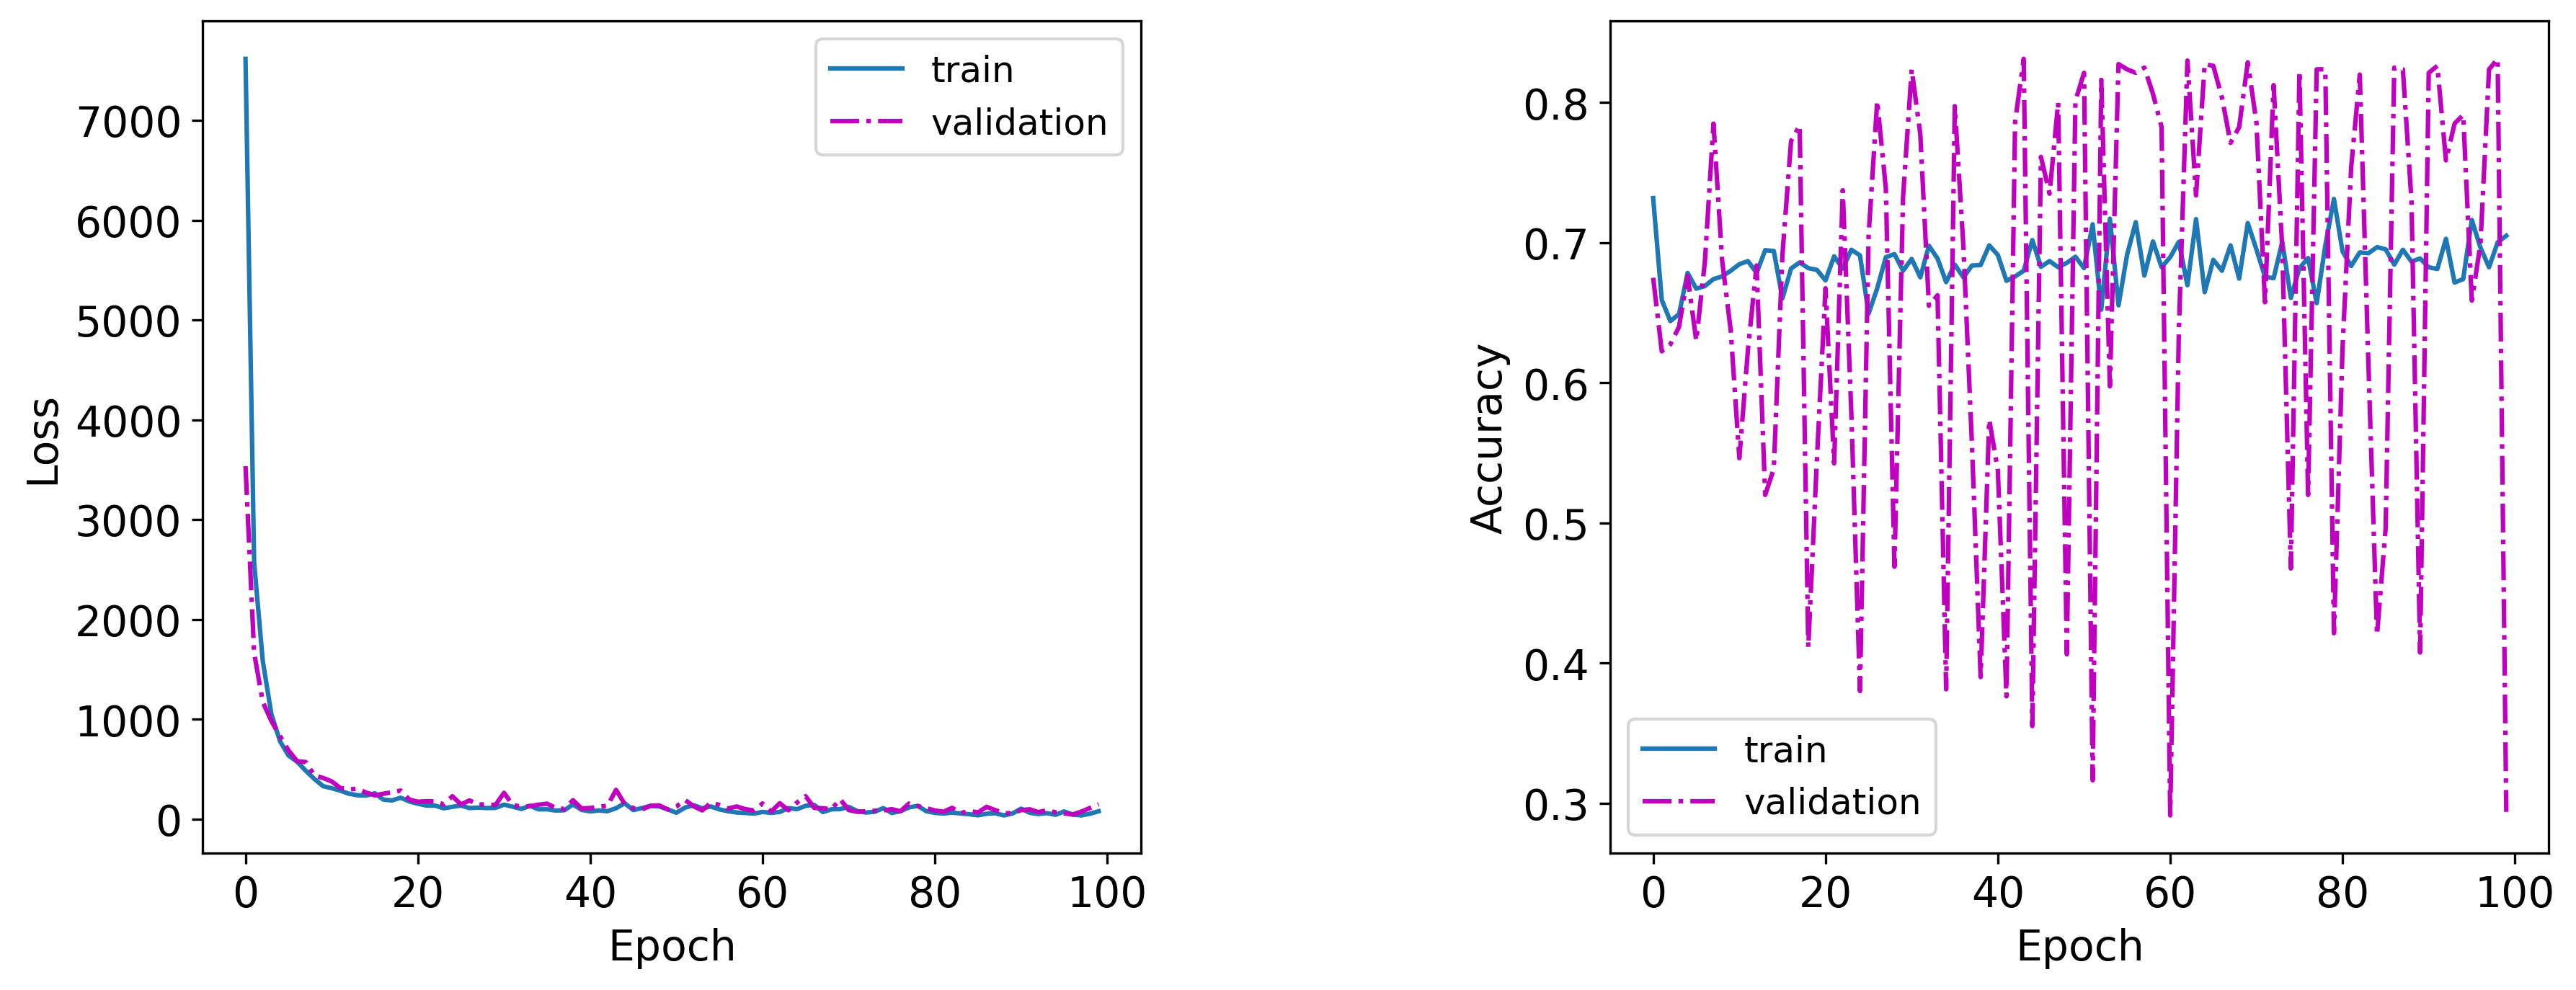

In [24]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

### Diagnóstico

El accuracy salió mucho peor de lo esperado. Antes de seguir:

1. Corra `X.describe()` en la celda de abajo y miren los rangos (min, max, mean) de las distintas columnas.
2. ¿Ve algo que podría estar afectando el entrenamiento por gradiente descendiente?
3. Le parece que la curva de la pérdida es suficiente para el diagnóstico del modelo?

In [25]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


Los datos no están escalados; las columnas `P#` presentan valores del orden de 10e5 pero en algunos casos son de orden 1. Los datos no están escalados.  
El análisis de la curva de pérdida no toma en cuenta la distribución de los datos, por lo que a priori puede servir pero no es lo suficientemente profundo como para validar/descartar un modelo.

### Nos olvidamos de escalar (por qué es necesario??)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

Escalamos sólo los datos del set entrenamiento (para evitar leakage)

In [28]:
scaler.fit(X_train)

StandardScaler()

In [29]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

### Reentrenamos la red

In [30]:
model_st = Sequential()
model_st.add(Dense(20, activation='relu', input_shape=(24,)))
model_st.add(Dense(20, activation='relu'))
model_st.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_st.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_st = model_st.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0) #verbose=0 para no mostrar el resultado en cada epoca

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


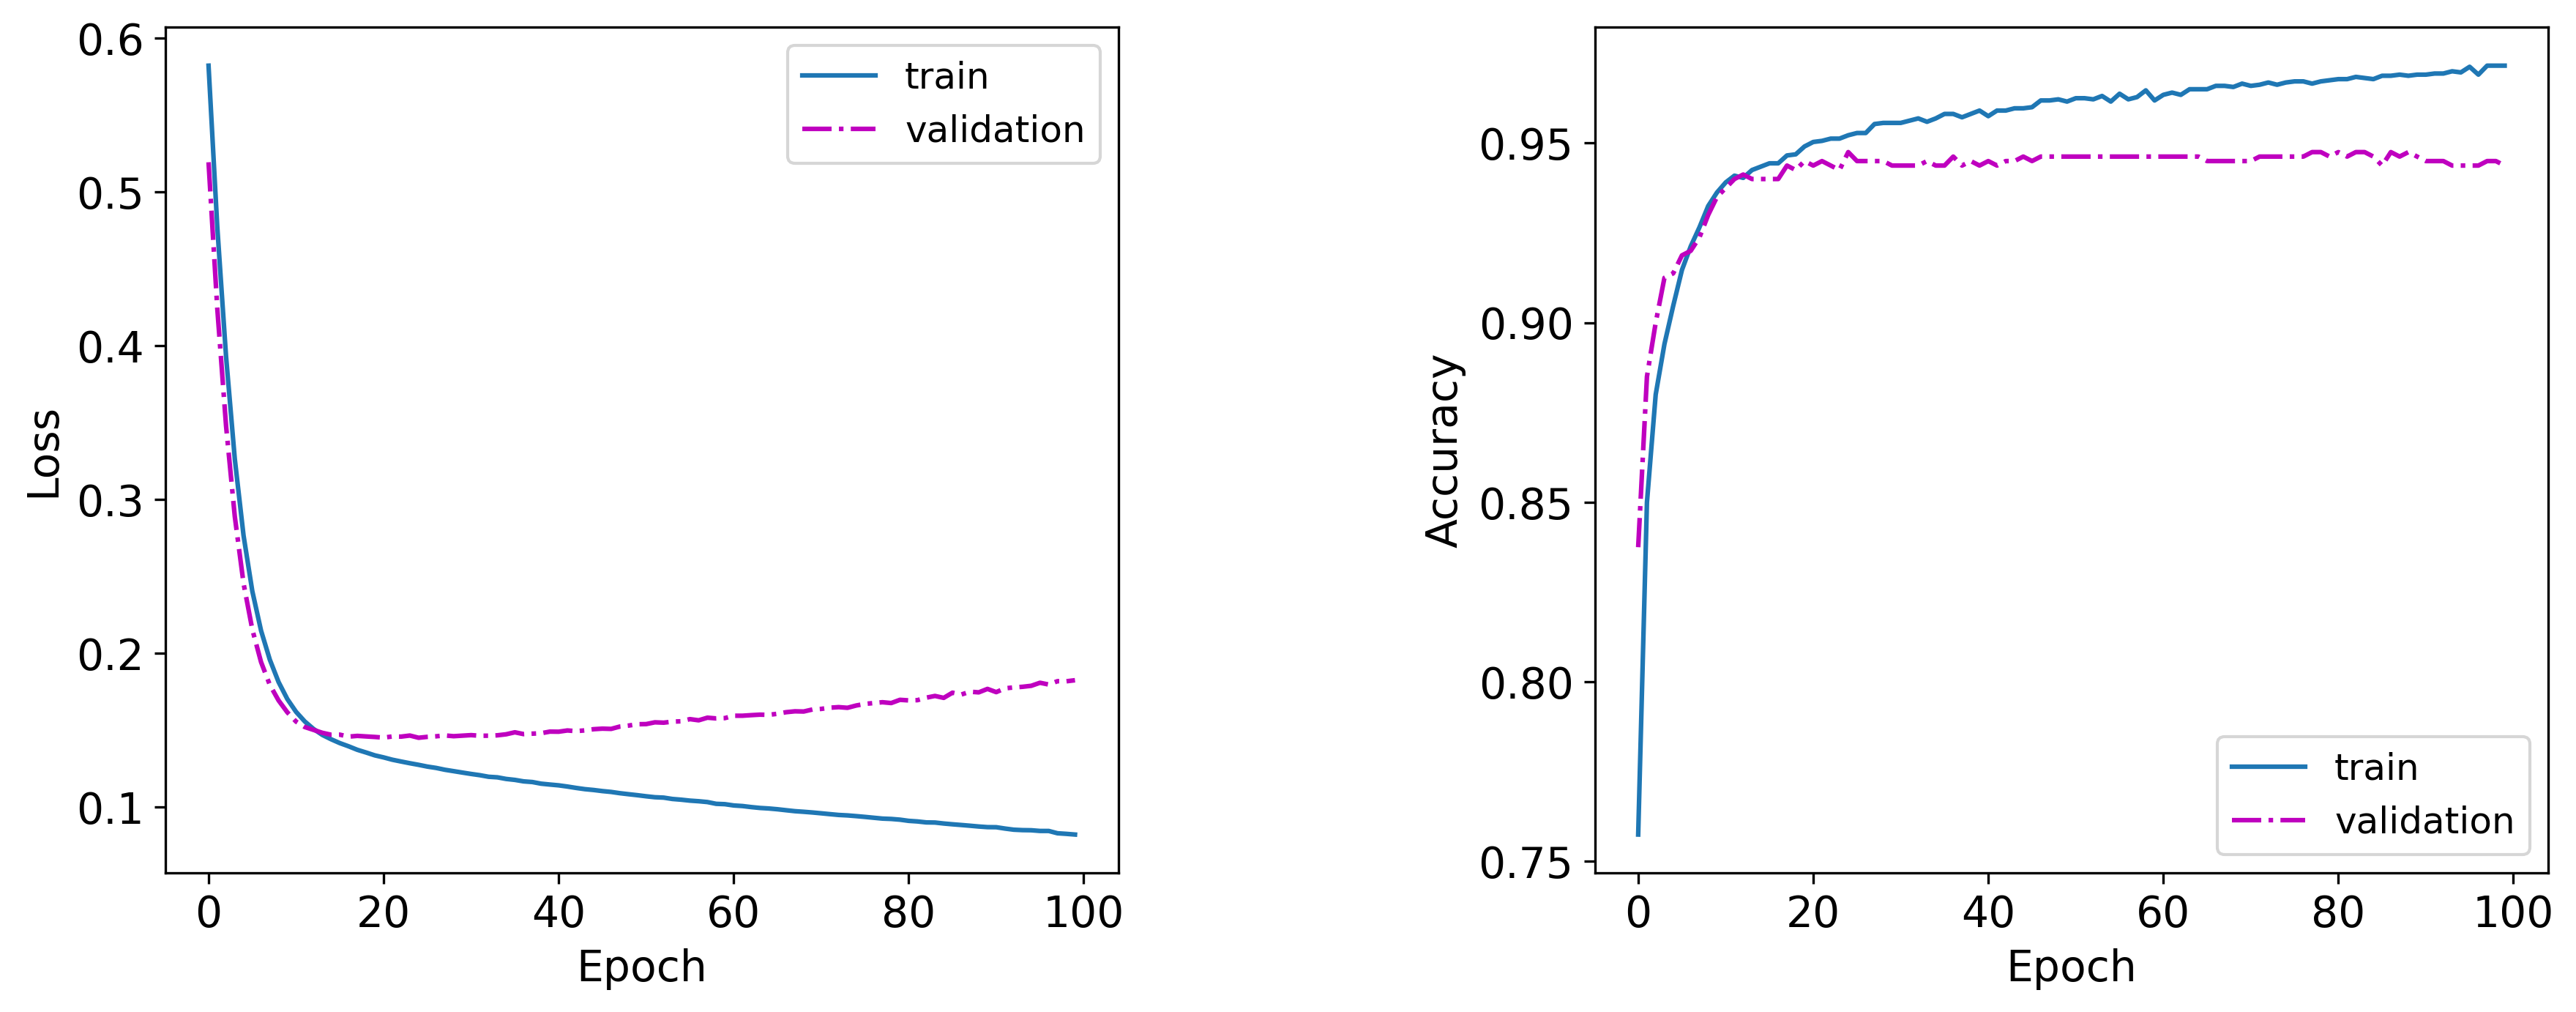

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_st.history['loss'], label = 'train')
plt.plot(mynet_st.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_st.history['accuracy'], label = 'train')
plt.plot(mynet_st.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

In [32]:
print(f"Final train accuracy: {mynet_st.history['accuracy'][-1]:.4f}")
print(f"Final val accuracy: {mynet_st.history['val_accuracy'][-1]:.4f}")
print(f"Final train loss: {mynet_st.history['loss'][-1]:.4f}")
print(f"Final val loss: {mynet_st.history['val_loss'][-1]:.4f}")

Final train accuracy: 0.9716
Final val accuracy: 0.9438
Final train loss: 0.0822
Final val loss: 0.1825


#### Ahora se ve mucho mejor el comportamiento de la red, y además se alcanza un accuracy similar a lo que obtuvimos con SVMs

Esto es común para datos tabulares, que tienen relaciones más simples y en general no contienen demasiados datos. Las NN funcionan mejor para datos más complejos, como audio, imágenes, texto

### Diagnóstico

Mire las curvas de loss y accuracy  (train vs. validación, con datos escalados).

1. ¿Hay separación entre las curvas de train y validación? ¿Es una separación que se mantiene estable, o una que crece con las épocas?
2. ¿esto califica como overfitting severo, overfitting leve, o no hay overfitting? Justifique mirando específicamente sus números, no una regla general.
3. Según su diagnóstico, ¿tiene sentido aplicar regularización acá, o el modelo ya está bien como está?

- Existe una separación que va creciendo junto con las épocas.  

- Hay un sobreajuste a los datos. El accuracy de validación es levemente menor al del train, pero respecto a la pérdida, notamos una diferencia un poco mayor, lo que sugiere el leve sobreajuste.  

- Sí, dado este leve sobreajuste observado. Lo más directo sería aplicar un EarlyStopping

### Ahora pruebe usted

La red original cuenta con dos capas ocultas de 20 neuronas cada una, ReLU, y salida sigmoide, entrenada con datos escalados. Usando ese mismo código como plantilla, construya y entrene tres variantes, una a la vez:

1. **Agregue una tercera capa oculta** (de 20 neuronas también). ¿Mejora, empeora, o no cambia mucho el accuracy de validación? ¿Por qué creen que pasa eso en este dataset específico?

2. **Cambie el tamaño de las capas ocultas** a algo mucho más chico (5 neuronas) y después a algo mucho más grande (100 neuronas). ¿Cuál entrena más lento? ¿Cuál muestra más señales de sobreajuste en las curvas de loss?

3. **Cambie la activación** de las capas ocultas de `relu` a `tanh`. Usen `dir(keras.activations)` si quieren ver más opciones. ¿Cambia la velocidad de convergencia?

Rellene la tabla de comparación

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) |0.9438 |0.1825 | Leve sobreajuste, sugiere regularización|
| 3 capas ocultas | 0.9262 | 0.2277 | Sobreajustado|
| Capas de 5 neuronas |0.9412 |0.1514 |Métricas no empeoran mucho, modelo más simple. |
| Capas de 100 neuronas |0.9262 |0.4428 |Brutalmente sobreajustado |
| Activación tanh |0.9312 |0.1942 | Comportamiento similar, levemente peor la pérdida. Converge (y sobreajusta) antes|

In [33]:
optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.001)
optimizer2 = tf.keras.optimizers.Adam(learning_rate=0.001)
optimizer3 = tf.keras.optimizers.Adam(learning_rate=0.001)
optimizer4 = tf.keras.optimizers.Adam(learning_rate=0.001)
# Variación con tercera capa oculta
variation1 = Sequential()
variation1.add(Dense(20, activation='relu', input_shape=(24,)))
variation1.add(Dense(20, activation='relu'))
variation1.add(Dense(20, activation='relu'))
variation1.add(Dense(1, activation='sigmoid'))

variation1.compile(loss='binary_crossentropy', optimizer=optimizer1, metrics=['accuracy'])

# Variación reduciendo a 5 neuronas y 100 neuronas
variation2 = Sequential()
variation2.add(Dense(5, activation='relu', input_shape=(24,)))
variation2.add(Dense(5, activation='relu'))
variation2.add(Dense(1, activation='sigmoid'))

variation2.compile(loss='binary_crossentropy', optimizer=optimizer2, metrics=['accuracy'])

variation3 = Sequential()
variation3.add(Dense(100, activation='relu', input_shape=(24,)))
variation3.add(Dense(100, activation='relu'))
variation3.add(Dense(1, activation='sigmoid'))

variation3.compile(loss='binary_crossentropy', optimizer=optimizer3, metrics=['accuracy'])

# Variación con activación tanh

variation4 = Sequential()
variation4.add(Dense(20, activation='tanh', input_shape=(24,)))
variation4.add(Dense(20, activation='tanh'))
variation4.add(Dense(1, activation='sigmoid'))

variation4.compile(loss='binary_crossentropy', optimizer=optimizer4, metrics=['accuracy'])

v1_hist = variation1.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, verbose=0)
v2_hist = variation2.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, verbose=0)
v3_hist = variation3.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, verbose=0)
v4_hist = variation4.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

In [34]:
hist_list = [mynet_st, v1_hist, v2_hist, v3_hist, v4_hist]
labels = ["Baseline", "3 hidden", "5 neurons", "100 neurons", "tanh"]
for i, hist in enumerate(hist_list):
  print(f"Métricas para modelo {labels[i]}")
  print(f"Accuracy: Train = {hist.history['accuracy'][-1]:.4f}, Val = {hist.history['val_accuracy'][-1]:.4f}")
  print(f"Loss: Train = {hist.history['loss'][-1]:.4f}, Val = {hist.history['val_loss'][-1]:.4f}")
  print()

Métricas para modelo Baseline
Accuracy: Train = 0.9716, Val = 0.9438
Loss: Train = 0.0822, Val = 0.1825

Métricas para modelo 3 hidden
Accuracy: Train = 0.9769, Val = 0.9262
Loss: Train = 0.0675, Val = 0.2277

Métricas para modelo 5 neurons
Accuracy: Train = 0.9506, Val = 0.9413
Loss: Train = 0.1206, Val = 0.1514

Métricas para modelo 100 neurons
Accuracy: Train = 1.0000, Val = 0.9262
Loss: Train = 0.0026, Val = 0.4428

Métricas para modelo tanh
Accuracy: Train = 0.9728, Val = 0.9312
Loss: Train = 0.0773, Val = 0.1942



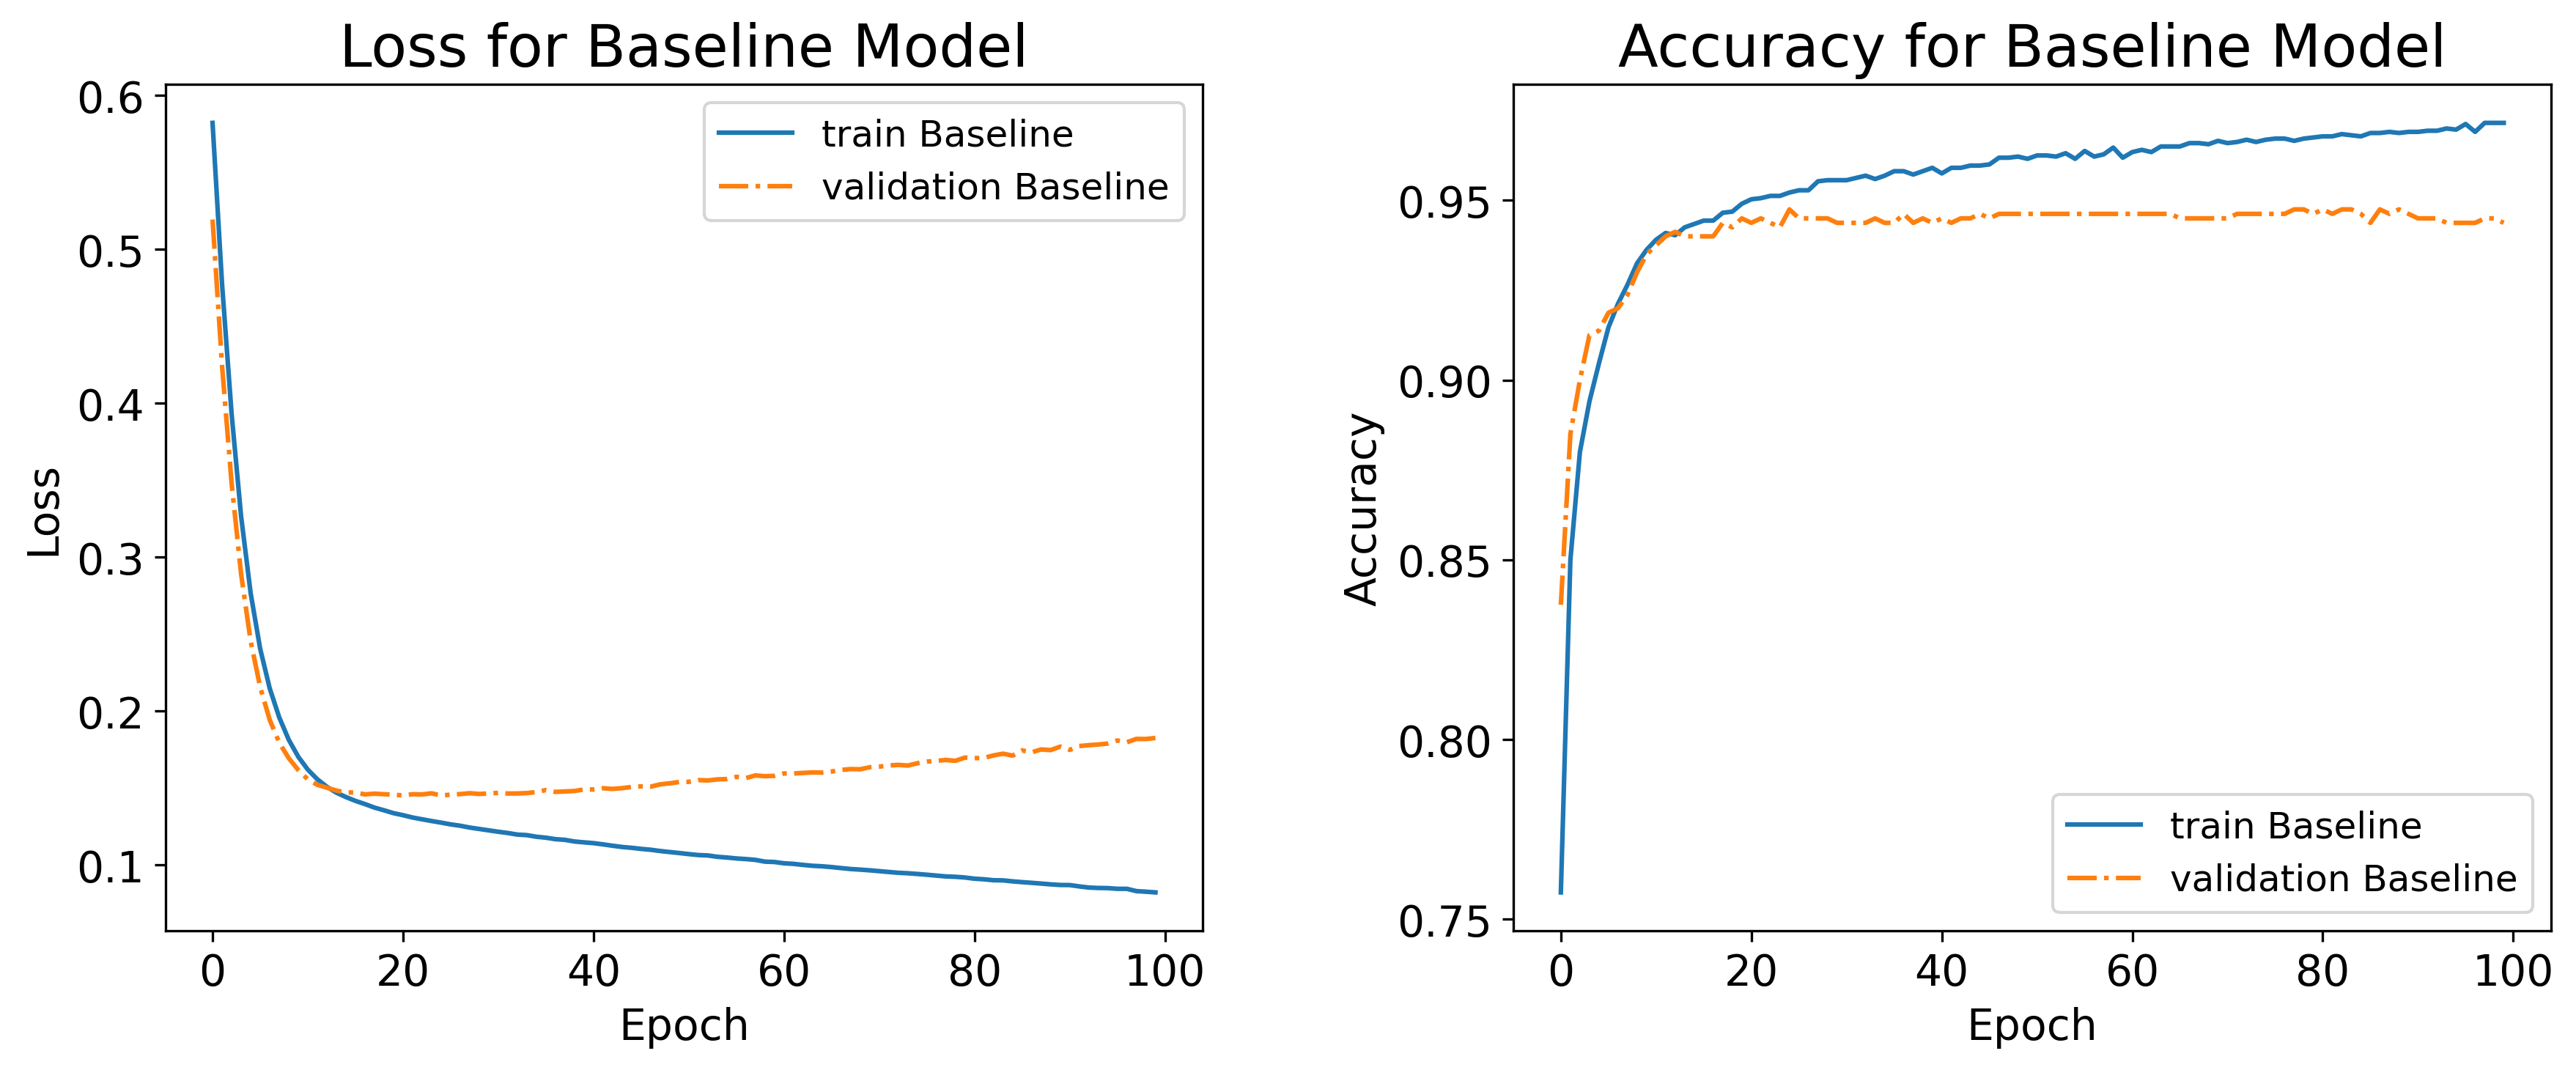

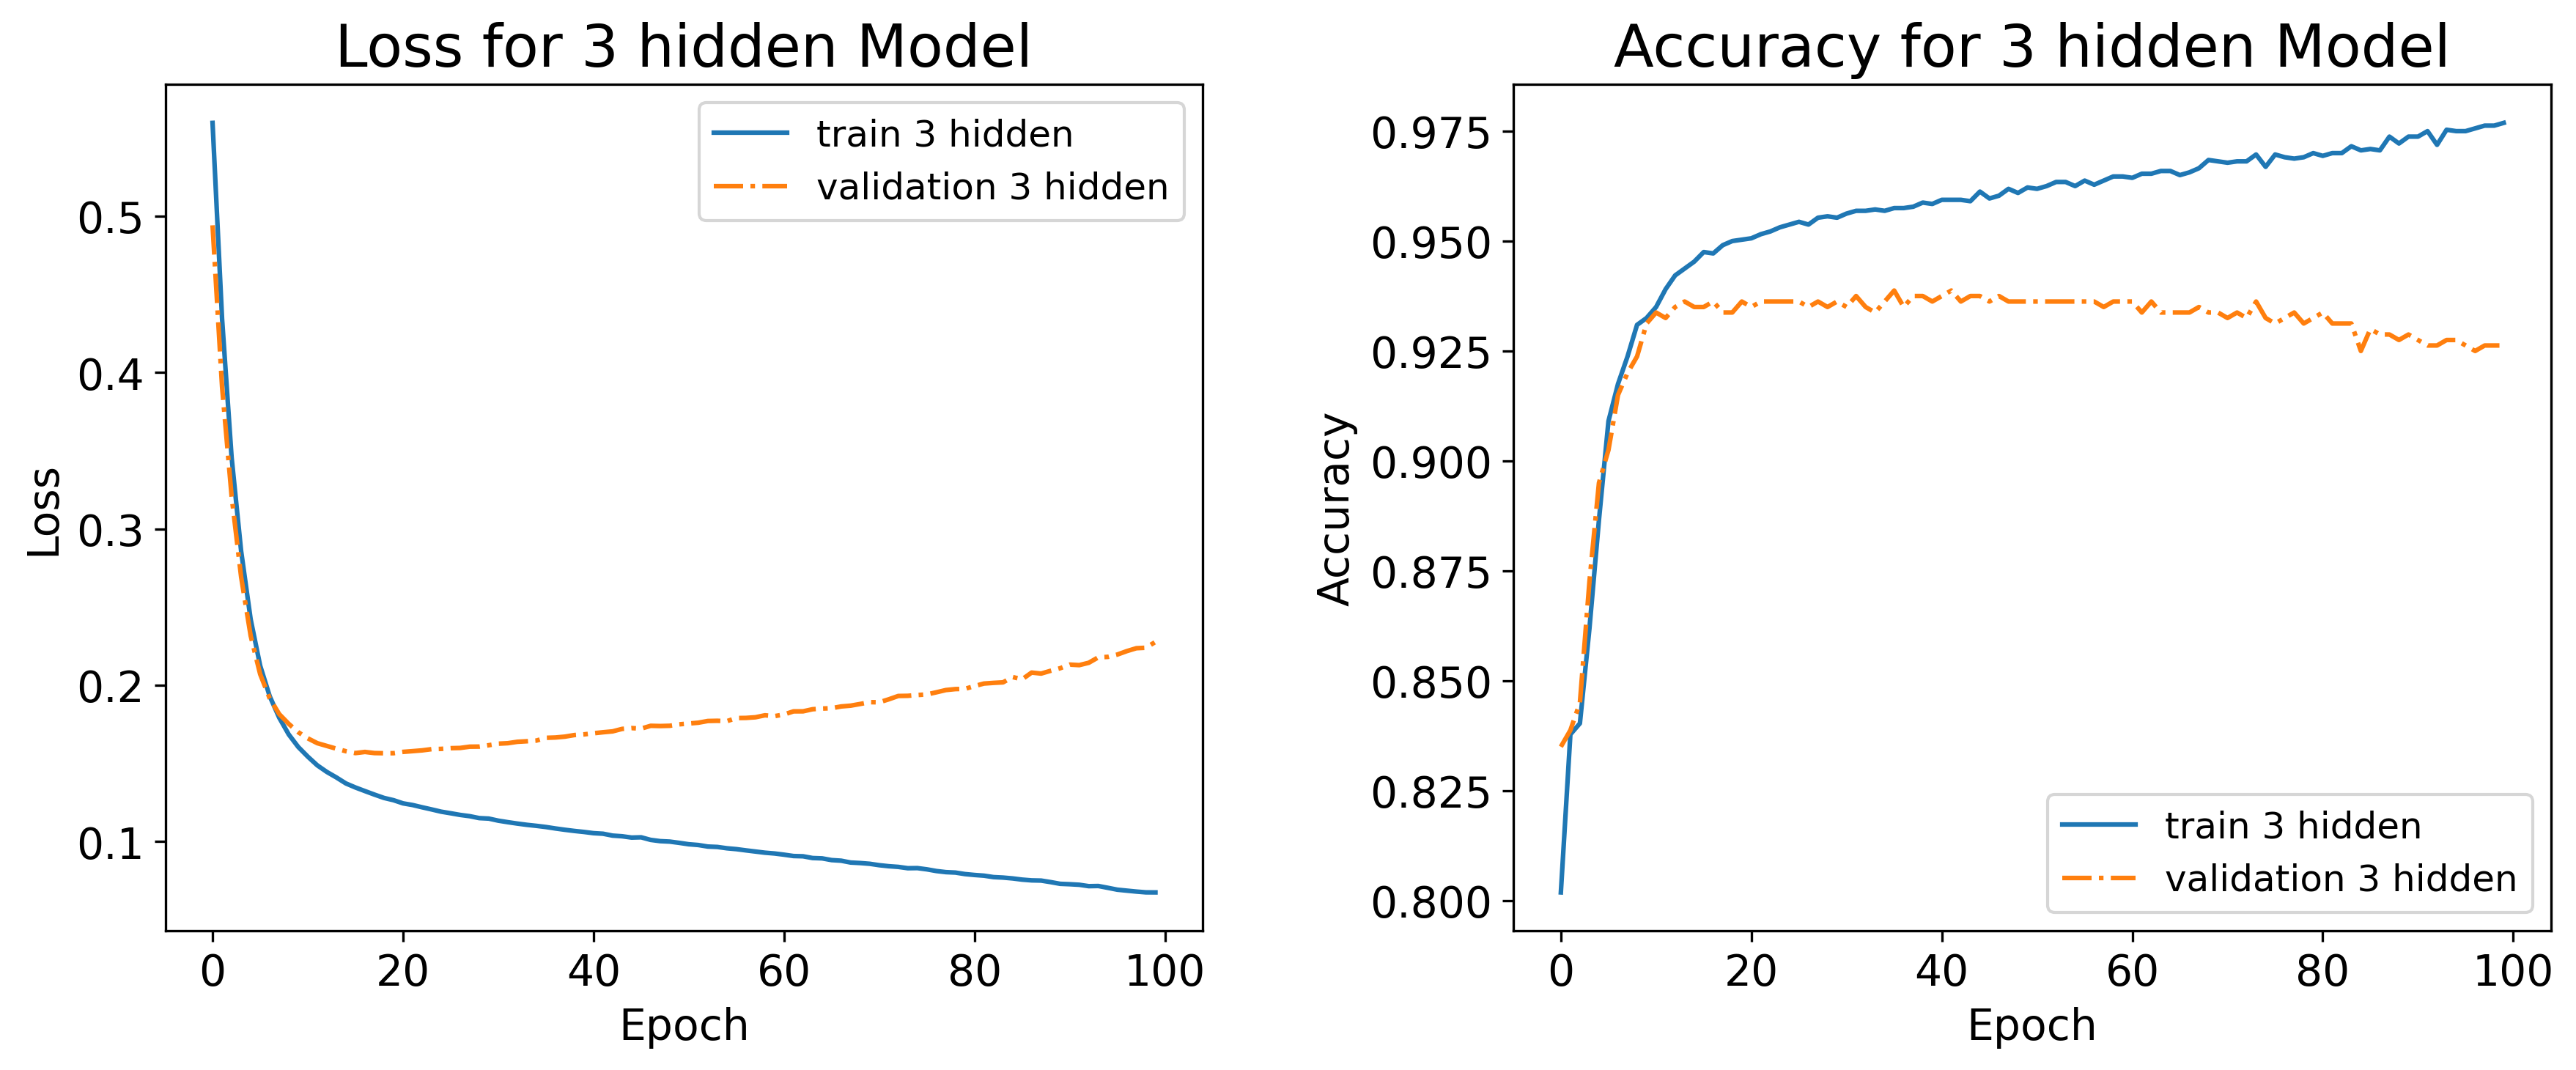

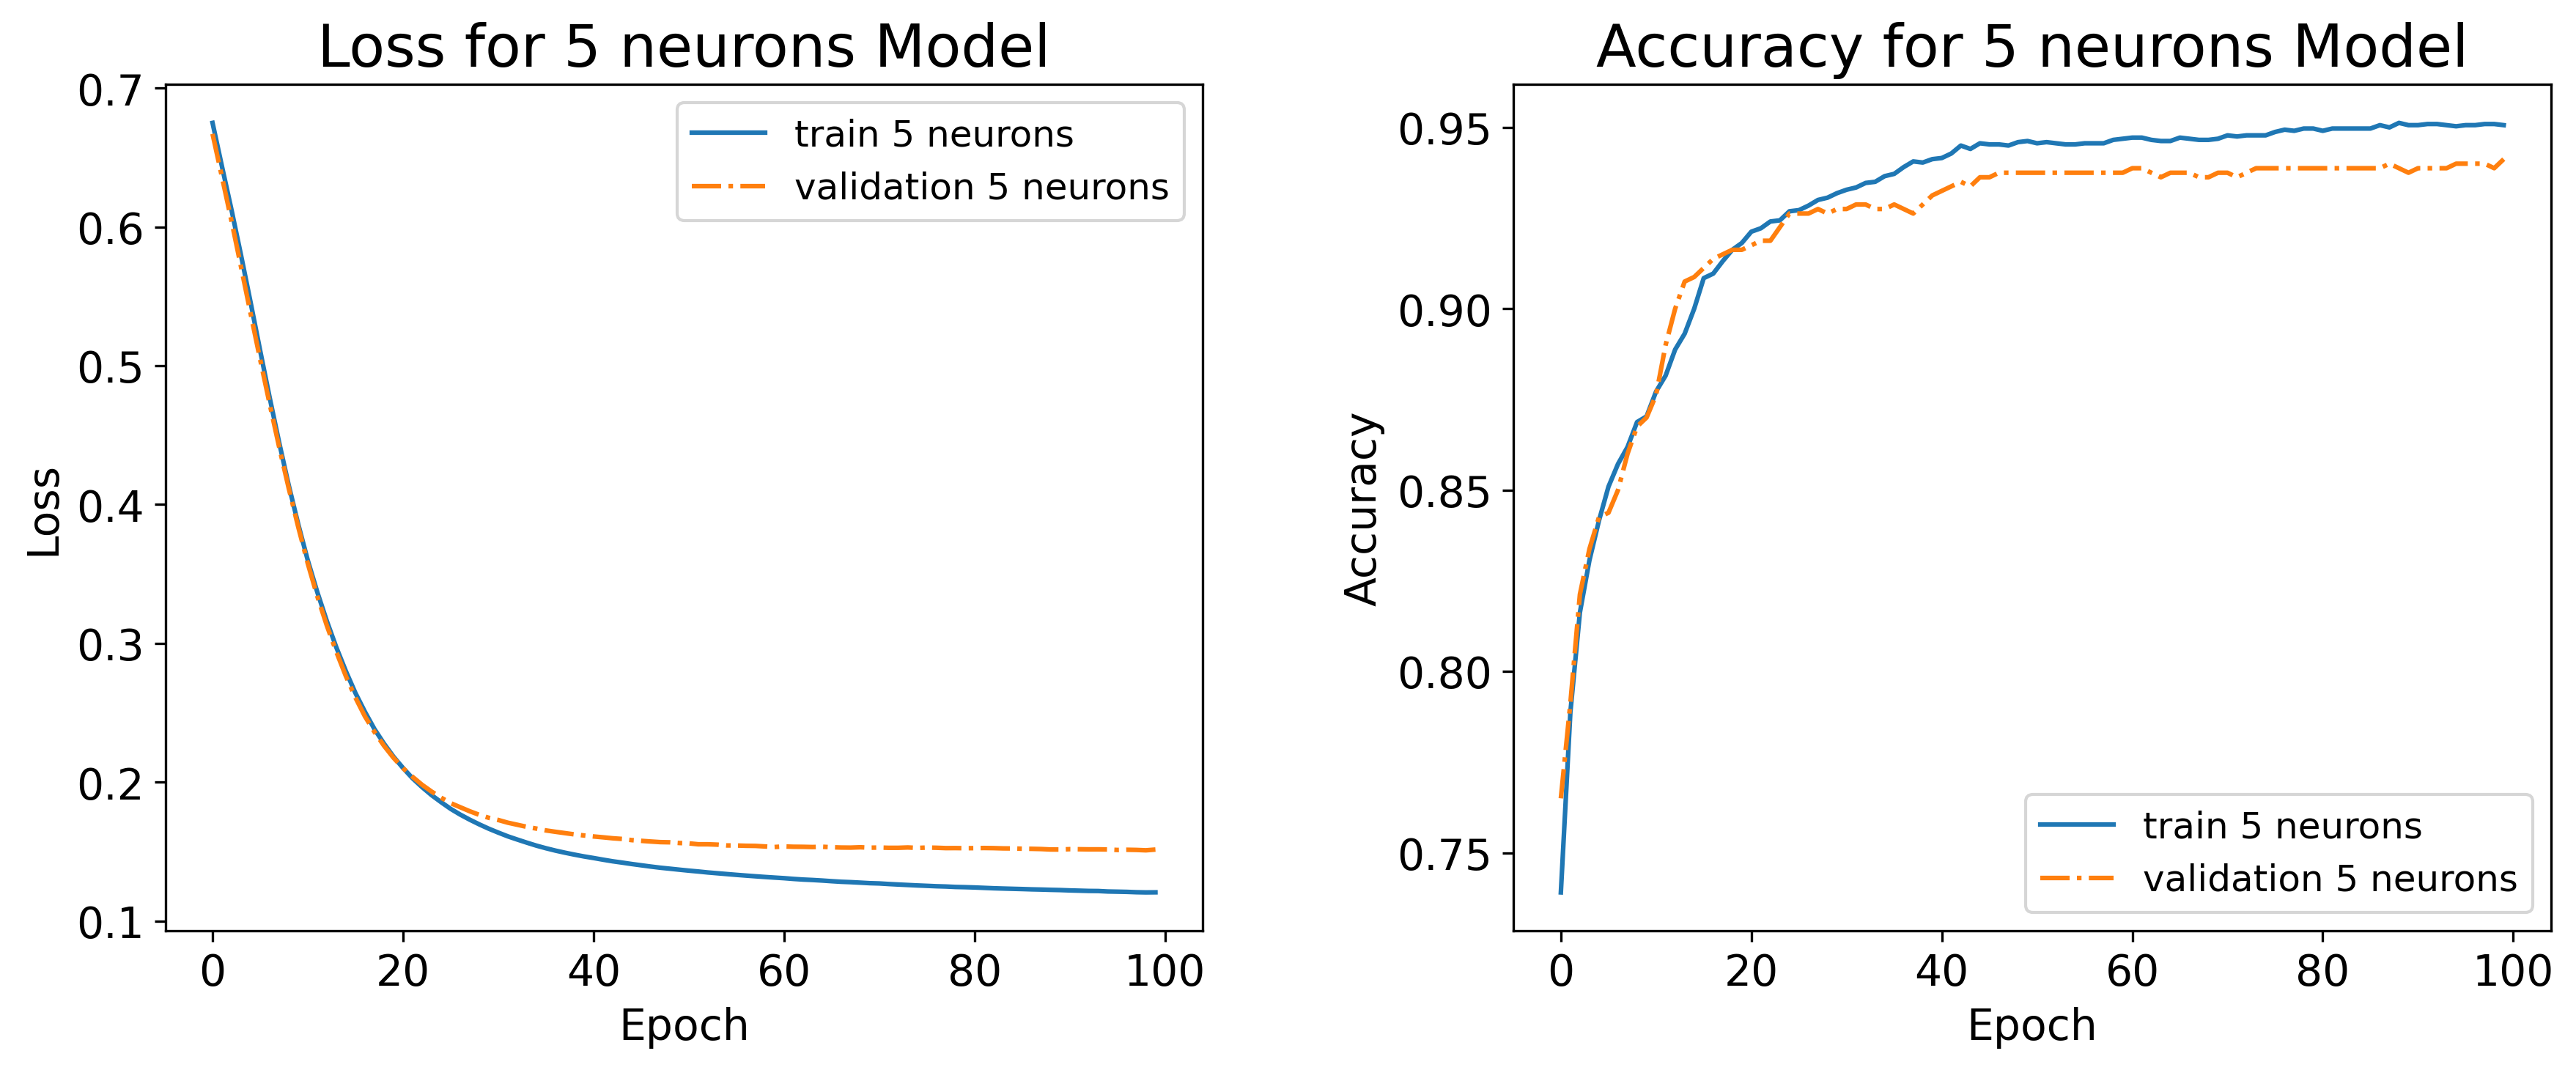

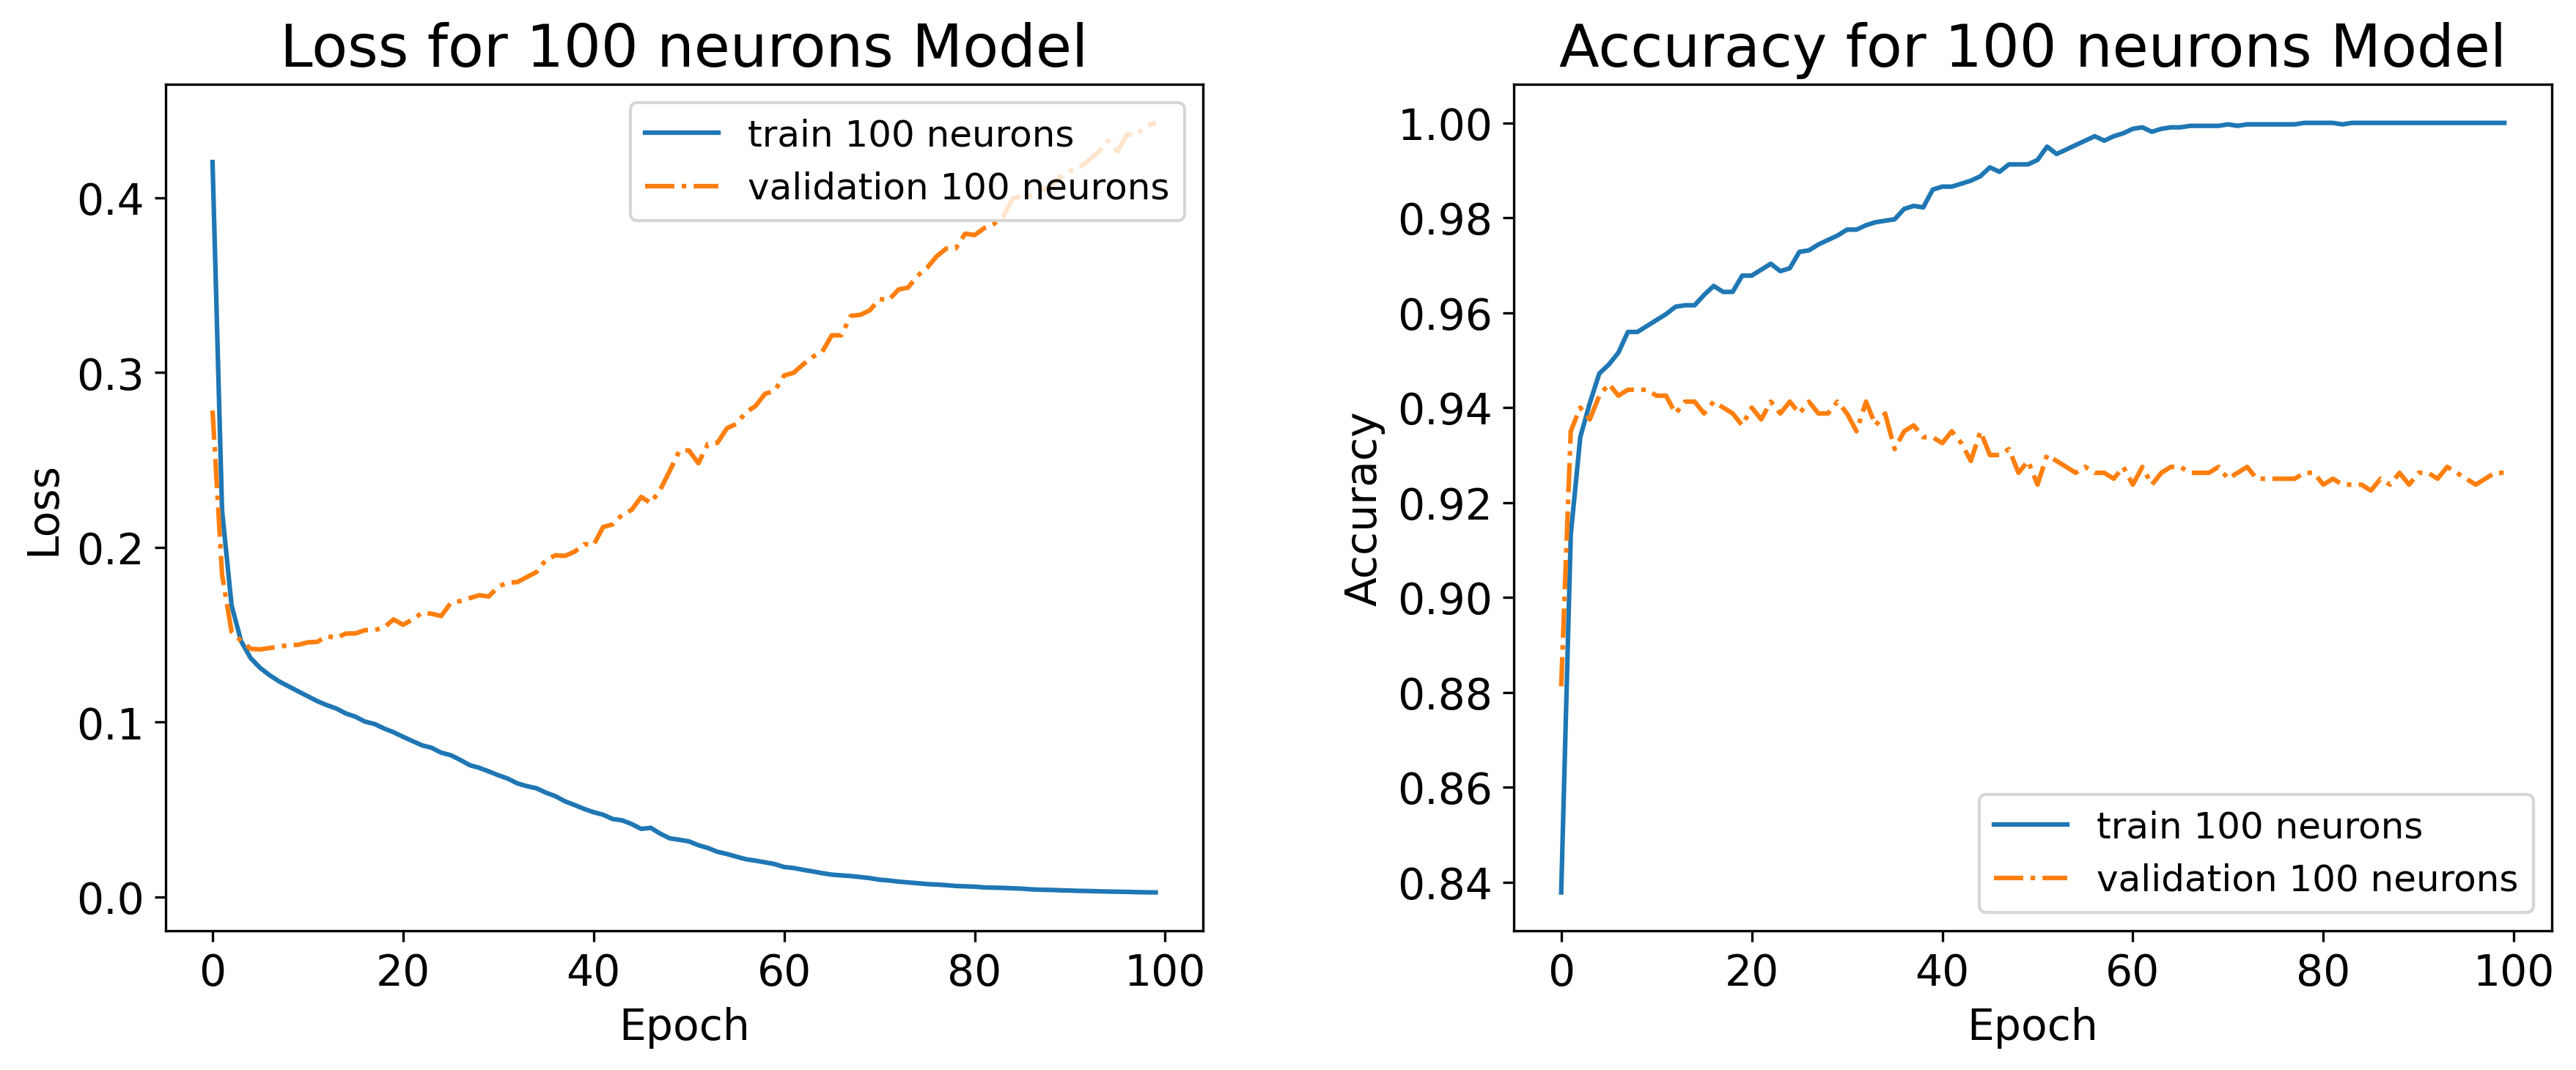

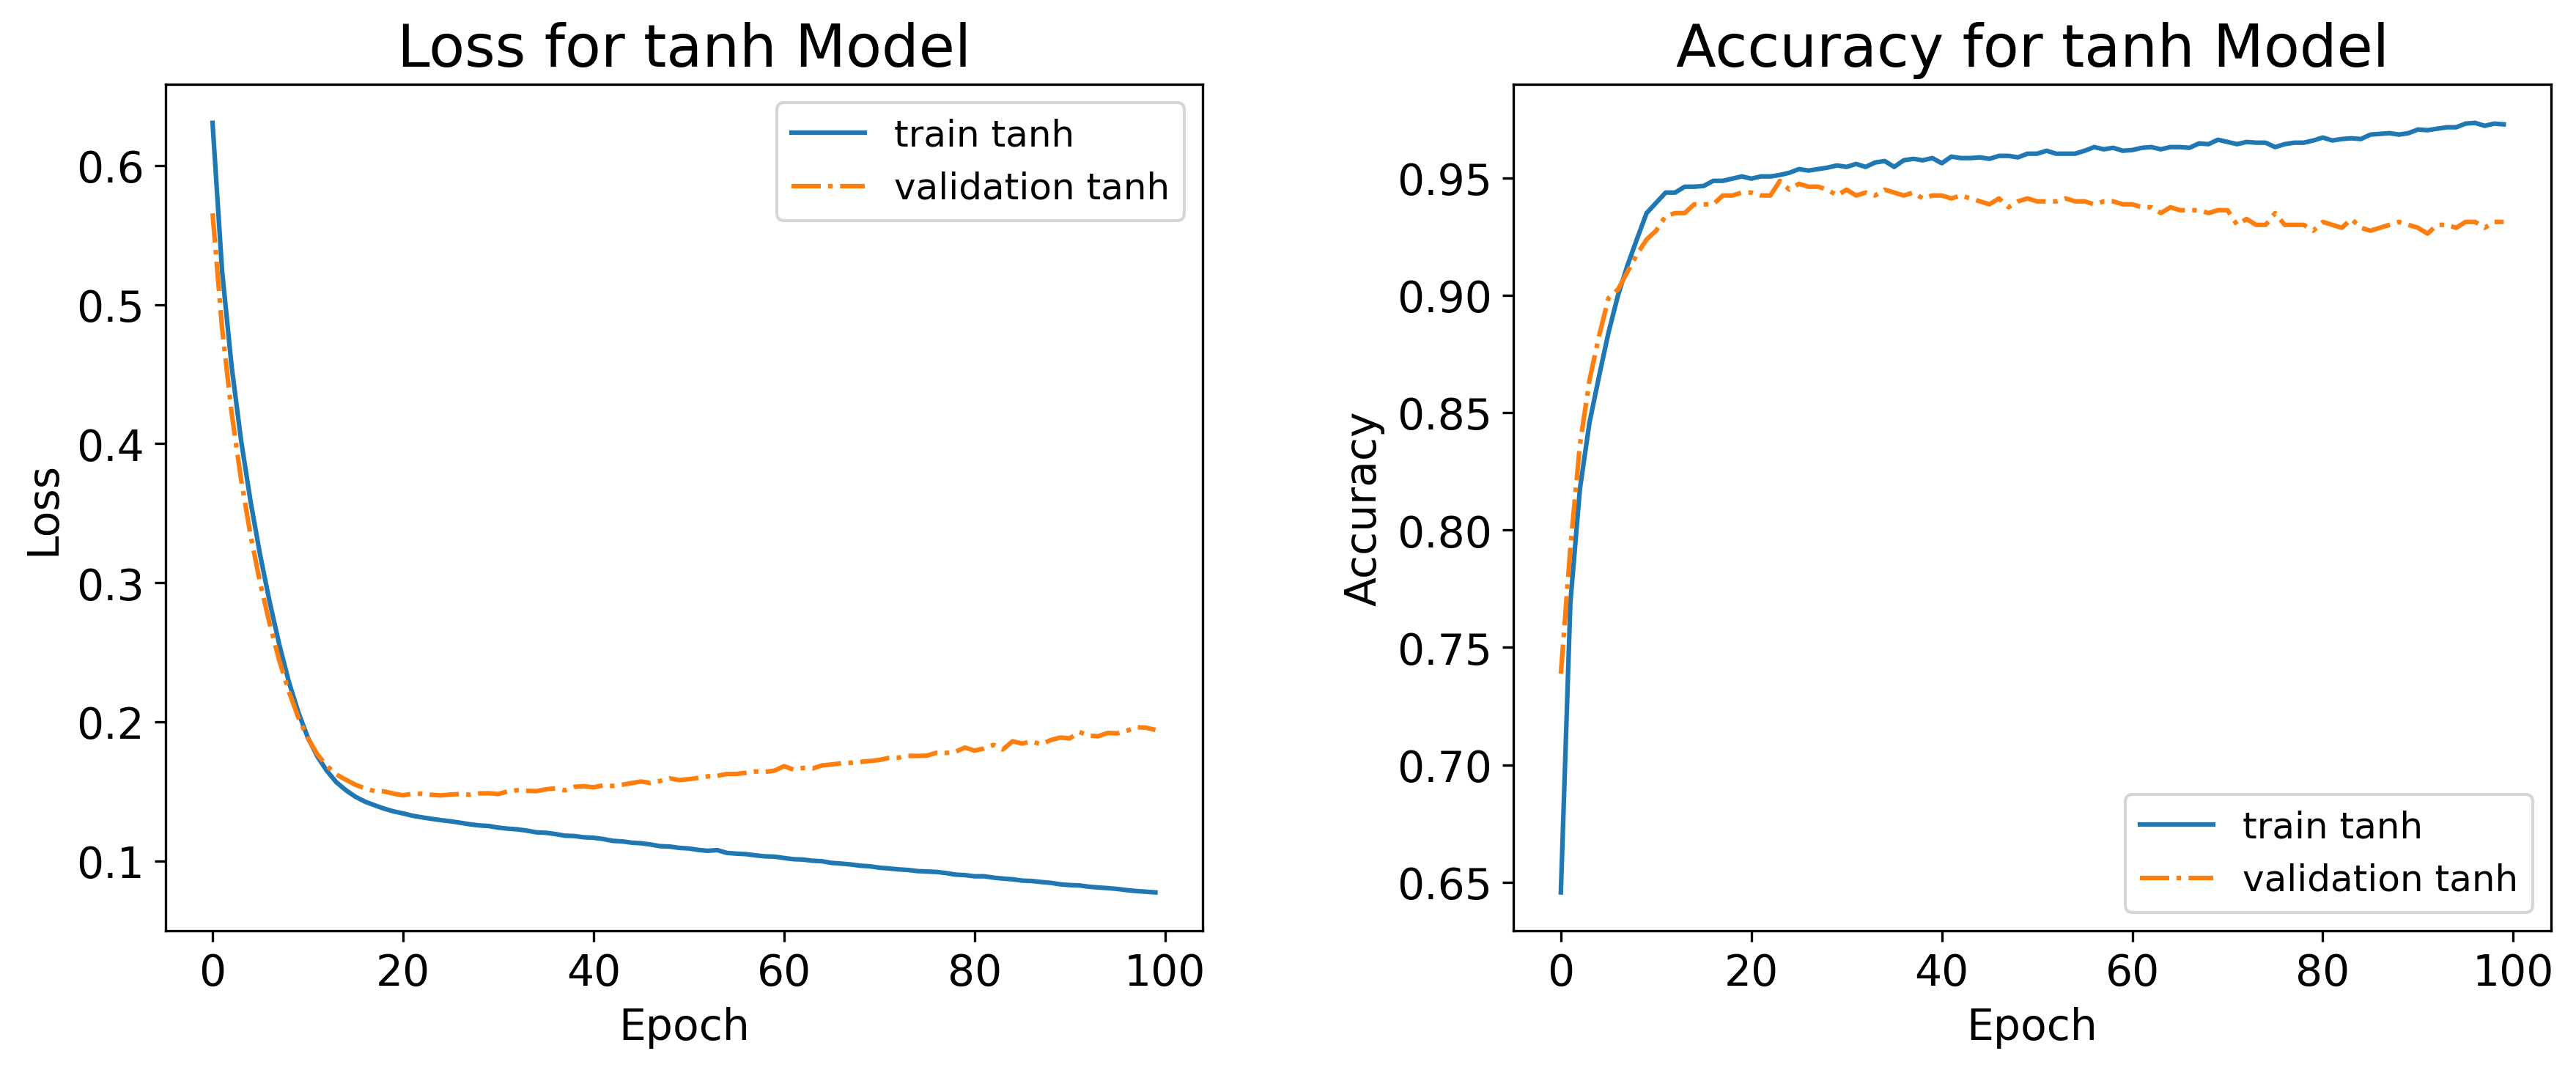

In [35]:
for i, hist in enumerate(hist_list):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

  # Plot Loss
  axes[0].plot(hist.history['loss'], label = f'train {labels[i]}')
  axes[0].plot(hist.history['val_loss'],'-.', label = f'validation {labels[i]}')
  axes[0].set_ylabel('Loss', fontsize = 14)
  axes[0].set_xlabel('Epoch', fontsize = 14)
  axes[0].legend(loc='upper right', fontsize = 12)
  axes[0].set_title(f'Loss for {labels[i]} Model')

  # Plot Accuracy
  axes[1].plot(hist.history['accuracy'], label = f'train {labels[i]}')
  axes[1].plot(hist.history['val_accuracy'], '-.', label = f'validation {labels[i]}')
  axes[1].set_ylabel('Accuracy', fontsize = 14)
  axes[1].set_xlabel('Epoch', fontsize = 14)
  axes[1].legend(fontsize = 12)
  axes[1].set_title(f'Accuracy for {labels[i]} Model')

  plt.subplots_adjust(wspace=0.3)
  plt.show() # Display each figure separately

# The commented out plt.savefig line is no longer needed for individual plots
# plt.savefig('ScaledNN.png', dpi= 300)

### Regularización (por qué es necesaria??)

Dos estrategias razonables acá: parar el entrenamiento antes (**early stopping**, ~época 20-30,
donde val deja de mejorar), o agregar regularización con **dropout** y ver si empuja la curva de validación
más alto. Probemos ambas y comparemos.

### Antes de correr

Va a probar dos estrategias para esta brecha train/val: dropout y early stopping. Antes de correr ninguna:

- ¿Cuál de las dos cree que va a dar mejor accuracy en validación?  
EarlyStopping, pues el sobreajuste se está dando por exceso de épocas, que es precisamente lo que corrige esta regularización.
- ¿Cuál cree que va a ser más rápida de entrenar (menos épocas efectivas)?
EarlyStopping pues va a derechamente cortar el entrenamiento cuando lo calcule conveniente.




### Dropout

In [36]:
model_dropout = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_dropout.add(Dense(20, activation='relu', input_shape=(24,)))

model_dropout.add(Dropout(0.2)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_dropout.add(Dense(20, activation='relu'))

model_dropout.add(Dropout(0.2)) #fracción de dropout

#Agregamos capa de salida

model_dropout.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_dropout.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [37]:
mynet_dropout = model_dropout.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

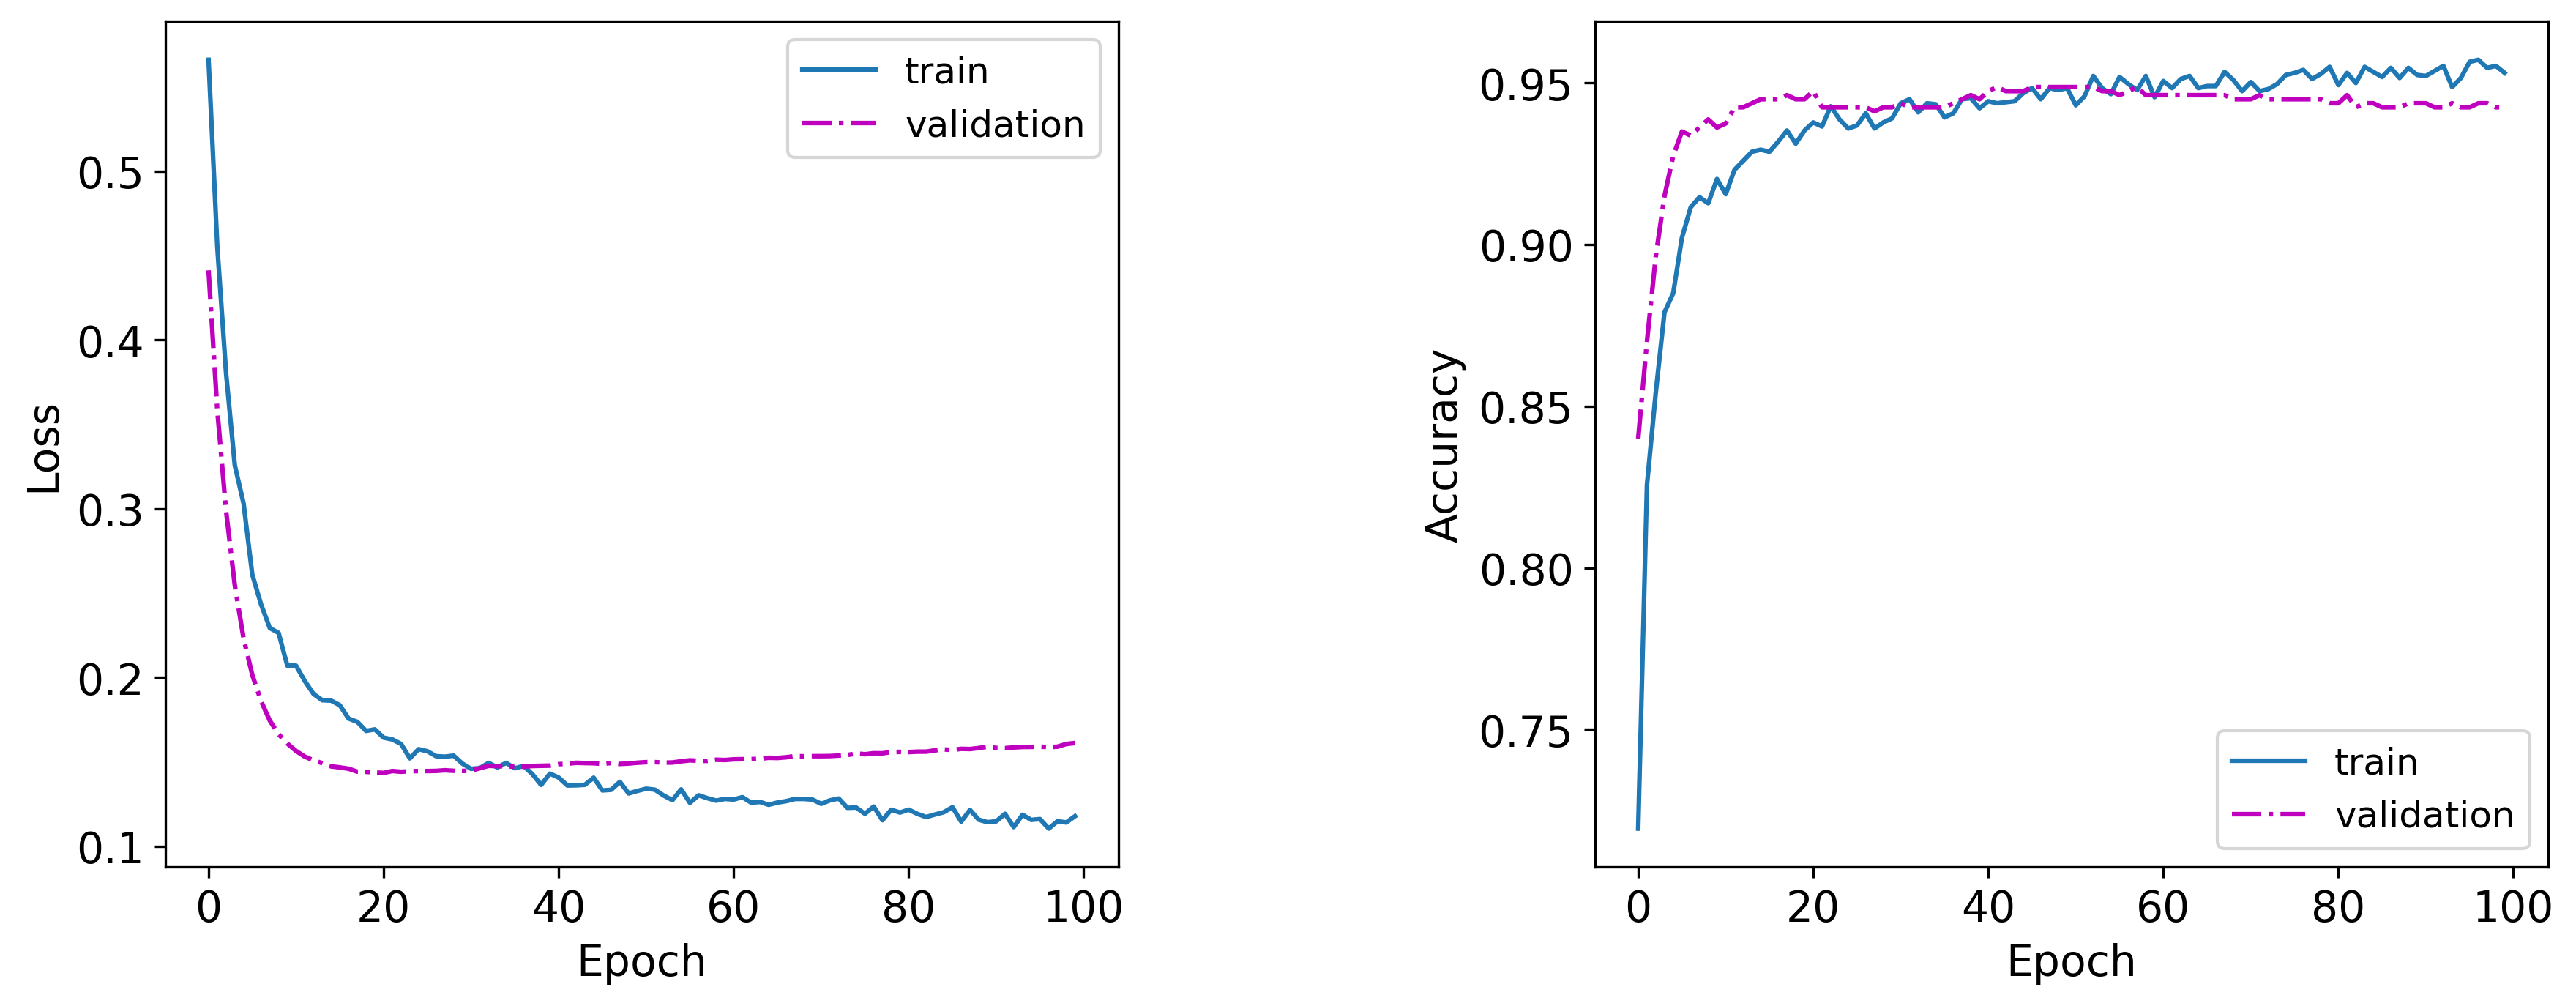

In [38]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_dropout.history['loss'], label = 'train')
plt.plot(mynet_dropout.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_dropout.history['accuracy'], label = 'train')
plt.plot(mynet_dropout.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

### Early Stopping

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Dense(20, activation='relu', input_shape=(24,)))
model_early.add(Dense(20, activation='relu'))
model_early.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_early.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

mynet_early = model_early.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, callbacks=[early_stop], verbose=0)

print(f"Se detuvo en la época: {len(mynet_early.history['loss'])}")

Se detuvo en la época: 50


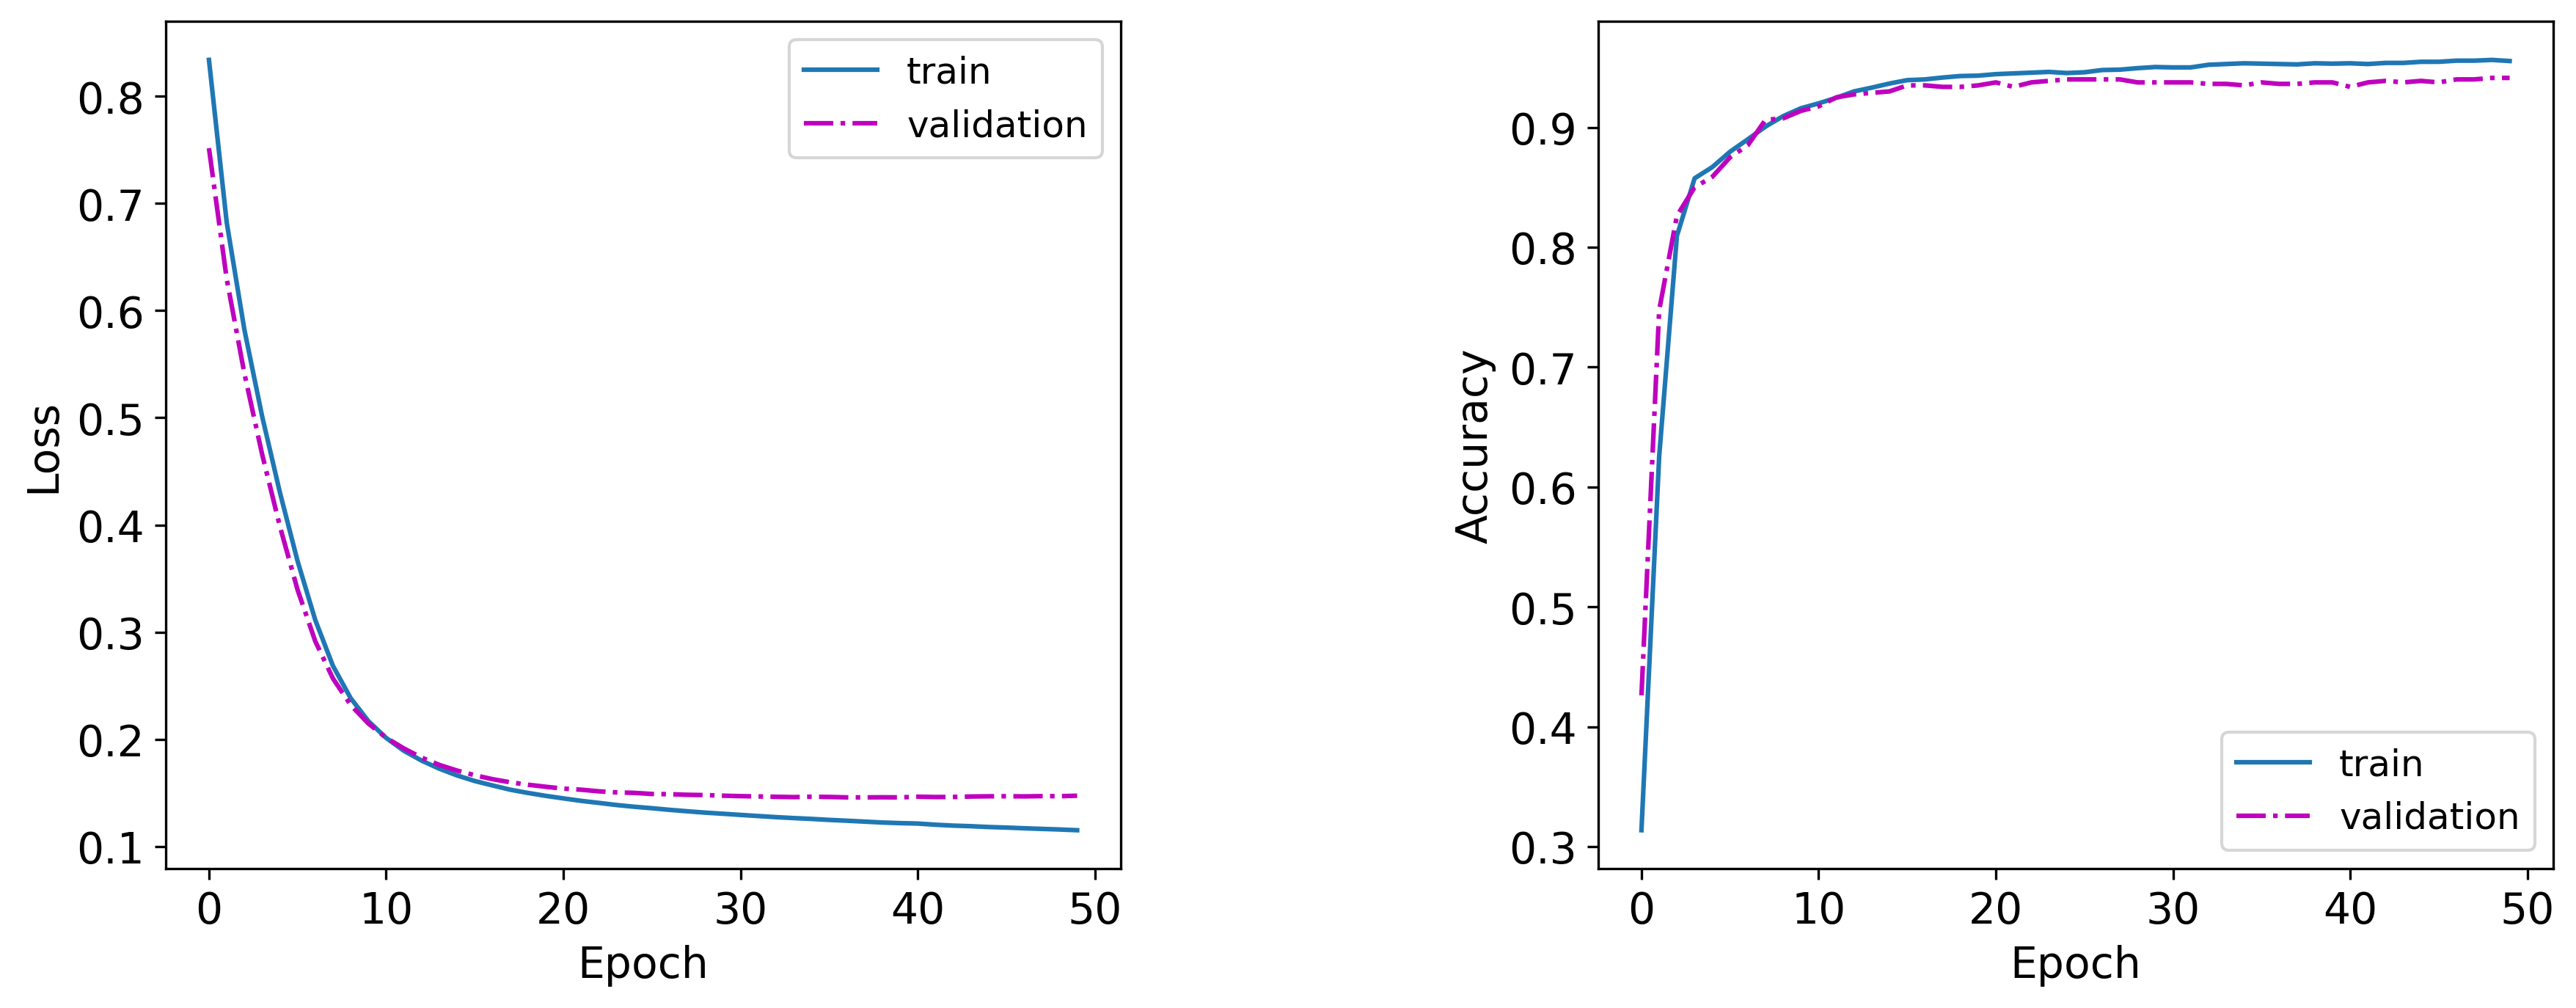

In [40]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_early.history['loss'], label = 'train')
plt.plot(mynet_early.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_early.history['accuracy'], label = 'train')
plt.plot(mynet_early.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('Regularized_Early_NN.png', dpi= 300)
#plt.show()

In [41]:
comparacion = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado + dropout",
     "val_acc": mynet_dropout.history['val_accuracy'][-1],
     "val_loss": mynet_dropout.history['val_loss'][-1]},
    {"modelo": "escalado + early stopping",
     "val_acc": mynet_early.history['val_accuracy'][-1],
     "val_loss": mynet_early.history['val_loss'][-1]},
])
comparacion

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.94375,0.182532
1,escalado + dropout,0.94250,0.161225
2,escalado + early stopping,0.94125,0.147324


In [42]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

modelos = {
    "sin regularizar": model_st,
    "dropout": model_dropout,
    "early stopping": model_early,
}

for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict(Xst_test, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["ttbar", "4top"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()

=== sin regularizar ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.83      0.83      0.83       162

    accuracy                           0.94      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.94      0.94      0.94      1000

AUC-ROC: 0.9732
Matriz de confusión:
[[810  28]
 [ 28 134]]

=== dropout ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.83      0.83       162

    accuracy                           0.95      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9795
Matriz de confusión:
[[812  26]
 [ 28 134]]

=== early stopping ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.85      0.85      0.85       16

In [43]:
comparacion = pd.DataFrame([
    {
        "modelo": nombre,
        "val_acc": modelo.evaluate(Xst_val, y_val, verbose=0)[1],
        "test_auc": roc_auc_score(y_test, modelo.predict(Xst_test, verbose=0).ravel()),
        "epocas": len(modelo.history.history['loss']) if hasattr(modelo, 'history') else None,
    }
    for nombre, modelo in modelos.items()
])
comparacion

,modelo,val_acc,test_auc,epocas
0,sin regularizar,0.94375,0.973187,100
1,dropout,0.94250,0.979485,100
2,early stopping,0.93750,0.977629,50


### Después de correr ambas: reflexión

Mire los números reales de dropout y early stopping.

1. Esperaba ese resultado? Explique
2. Dropout actúa *durante* el entrenamiento (apagando neuronas en cada paso). Early stopping actúa *deteniendo* el entrenamiento en un punto. ¿Por qué una de las dos estrategias podría funcionar mejor que la otra en este dataset específico, dado su tamaño y la arquitectura que están usando?
3. ¿Tendría sentido combinar ambas (dropout + early stopping) en vez de elegir una sola? ¿Por qué sí o por qué no?
4. Pruebe distintos valores de dropout y early stopping y discuta cómo cambian los resultados.

- Sí, era de esperar una mejora no tan significativa. Ambas regularizaciones logran leves mejoras en ambas métricas y en particular Dropout resultó mejor respecto a EarlyStopping.  
- El modelo base ya presenta métricas medianamente buenas, pero se ve que el pasar de las épocas tiende a sobreajustar. EarlyStopping resulta idóneo para esta situación al cortar el entrenamiento antes que el modelo aprenda ruido en un dataset que es pequeño. Dropout por otro lado robustece el modelo desde su arquitectura misma, lo cual puede ayudar al tratar de ajustar un modelo que es demasiado complejo respecto al dataset.  
- Sí tiene sentido. Son técnicas que apuntan a distintas matices del modelo y son perfectamente complementables. Dropout regulariza durante el entrenamiento y EarlyStopping corta este entrenamiento antes de que empeoren las métricas por lo que considerar ambos sería bastante efectivo


In [50]:
from tensorflow.keras.callbacks import EarlyStopping

# Modelo 1: Dropout 0.1, no Early Stopping
model_d_01 = Sequential()
model_d_01.add(Dense(20, activation='relu', input_shape=(24,)))
model_d_01.add(Dropout(0.1))
model_d_01.add(Dense(20, activation='relu'))
model_d_01.add(Dropout(0.1))
model_d_01.add(Dense(1, activation='sigmoid'))
optimizer_d_01 = tf.keras.optimizers.Adam(learning_rate=0.001)
model_d_01.compile(loss='binary_crossentropy', optimizer=optimizer_d_01, metrics=['accuracy'])
mynet_d_01 = model_d_01.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

# Modelo 2: Dropout 0.3, no Early Stopping
model_d_03 = Sequential()
model_d_03.add(Dense(20, activation='relu', input_shape=(24,)))
model_d_03.add(Dropout(0.3))
model_d_03.add(Dense(20, activation='relu'))
model_d_03.add(Dropout(0.3))
model_d_03.add(Dense(1, activation='sigmoid'))
optimizer_d_03 = tf.keras.optimizers.Adam(learning_rate=0.001)
model_d_03.compile(loss='binary_crossentropy', optimizer=optimizer_d_03, metrics=['accuracy'])
mynet_d_03 = model_d_03.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

# Modelo 3: No Dropout, Early Stopping (patience=5)
model_es_5 = Sequential()
model_es_5.add(Dense(20, activation='relu', input_shape=(24,)))
model_es_5.add(Dense(20, activation='relu'))
model_es_5.add(Dense(1, activation='sigmoid'))
optimizer_es_5 = tf.keras.optimizers.Adam(learning_rate=0.001)
model_es_5.compile(loss='binary_crossentropy', optimizer=optimizer_es_5, metrics=['accuracy'])
early_stop_5 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mynet_es_5 = model_es_5.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, callbacks=[early_stop_5], verbose=0)

# Modelo 4: Dropout 0.2, Early Stopping (patience=10)
model_d_02_es_10 = Sequential()
model_d_02_es_10.add(Dense(20, activation='relu', input_shape=(24,)))
model_d_02_es_10.add(Dropout(0.2))
model_d_02_es_10.add(Dense(20, activation='relu'))
model_d_02_es_10.add(Dropout(0.2))
model_d_02_es_10.add(Dense(1, activation='sigmoid'))
optimizer_d_02_es_10 = tf.keras.optimizers.Adam(learning_rate=0.001)
model_d_02_es_10.compile(loss='binary_crossentropy', optimizer=optimizer_d_02_es_10, metrics=['accuracy'])
early_stop_10 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mynet_d_02_es_10 = model_d_02_es_10.fit(Xst_train, y_train, validation_data=(Xst_val, y_val), epochs=100, batch_size=200, callbacks=[early_stop_10], verbose=0)


comparacion_nuevos = pd.DataFrame([
    {
        "modelo": "Dropout 0.1",
        "val_acc": mynet_d_01.history['val_accuracy'][-1],
        "val_loss": mynet_d_01.history['val_loss'][-1],
        "epocas": len(mynet_d_01.history['loss'])
    },
    {
        "modelo": "Dropout 0.3",
        "val_acc": mynet_d_03.history['val_accuracy'][-1],
        "val_loss": mynet_d_03.history['val_loss'][-1],
        "epocas": len(mynet_d_03.history['loss'])
    },
    {
        "modelo": "Early Stopping (patience=5)",
        "val_acc": mynet_es_5.history['val_accuracy'][-1],
        "val_loss": mynet_es_5.history['val_loss'][-1],
        "epocas": len(mynet_es_5.history['loss'])
    },
    {
        "modelo": "Dropout 0.2 + Early Stopping (patience=10)",
        "val_acc": mynet_d_02_es_10.history['val_accuracy'][-1],
        "val_loss": mynet_d_02_es_10.history['val_loss'][-1],
        "epocas": len(mynet_d_02_es_10.history['loss'])
    }
])

print("Métricas de los nuevos modelos:")
print(comparacion_nuevos)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas de los nuevos modelos:
                                       modelo  val_acc  val_loss  epocas
0                                 Dropout 0.1  0.94500  0.168683     100
1                                 Dropout 0.3  0.94250  0.150467     100
2                 Early Stopping (patience=5)  0.93375  0.152737      42
3  Dropout 0.2 + Early Stopping (patience=10)  0.93625  0.145039      42


Notar que un earlystopping muy corto puede impedir que el modelo termine de entrenar con totalidad, como vemos en el tercer caso. Notamos una baja relevante para la combinación en la métrica de accuracy en 0.01 puntos lo cual sugiere que estamos regularizando muy fuerte, o el modelo en sí no es estable en esta métrica.

### Optimización de hiperparámetros

Usaremos [`keras_tuner`](https://keras.io/keras_tuner/) para optimizar los hiperparámetros de la arquitectura de la red

### Antes de correr la búsqueda

Con lo que ya sabe del dataset y de los experimentos anteriores, responda:

- ¿Cuántas capas ocultas cree que va a preferir el mejor modelo?  
2
- ¿Dropout va a terminar en 0.0 o en un valor alto?  
Debiera terminar en valores bajos, no espero que se apaguen muchas neuronas en el mejor modelo
- ¿El learning rate óptimo va a ser más cercano a 0.0001 o a 0.01?
Más cercano a 0.01. Ir más pequeño tardaría más en converger, y por sí se hacen pocas épocas.

In [45]:
!pip install keras-tuner  #(correr una vez en Colab)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.3 MB/s eta 0:00:00


In [46]:
import keras_tuner as kt

def build_model_tuner(hp):
    model = Sequential()

    #prueba con ndistintos numeros de neuronas, desde 8 a 64, cada 8,
    n_neurons = hp.Int("n_neurons", min_value=8, max_value=64, step=8)
    # activation = hp.Choice("activation", values=["relu", "tanh"])

    #construye la capa con la cantidad de neuronas que fijo en el paso anterior (cada capa con el mismo numero de neuronas)
    model.add(Dense(n_neurons, activation='relu', input_shape=(24,)))

    #numero de capas ocultas (1, 2, o 3)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))

    #tasa de dropout (0.1-0.5, en pasos de 0.1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    #la capa de salida queda fija, para la clasificacion binaria
    model.add(Dense(1, activation='sigmoid'))

    #tasa de aprendizaje, entre 0.0001 y 0.01
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

#prueba solo combinaciones aleatorias para reducir costo computacional
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_accuracy",
    max_trials=15,          # número de combinaciones a probar
    executions_per_trial=1,
    directory="tuner_resultados",
    project_name="particle_id",
)

tuner.search(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=30,
    batch_size=200,
    verbose=1,
)

Trial 15 Complete [00h 00m 09s]
val_accuracy: 0.9362499713897705

Best val_accuracy So Far: 0.9487500190734863
Total elapsed time: 00h 02m 35s


In [47]:
# Mejor modelo encontrado
mejores_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros:")
for param in mejores_hp.values:
    print(f"  {param}: {mejores_hp.values[param]}")



Mejores hiperparámetros:
  n_neurons: 40
  n_hidden: 3
  dropout_rate: 0.1
  learning_rate: 0.002488466363710587


### Evaluamos finalmente el modelo con el set de prueba, que sólo se usa en el paso final

In [48]:
mejor_modelo = tuner.get_best_models(1)[0]
scores = mejor_modelo.evaluate(Xst_test, y_test, verbose=0)
print(f"\nAccuracy en test: {scores[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Accuracy en test: 0.9490


In [49]:
# Resumen de los mejores trials
tuner.results_summary(num_trials=5)

Results summary
Results in tuner_resultados/particle_id
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 01 summary
Hyperparameters:
n_neurons: 40
n_hidden: 3
dropout_rate: 0.1
learning_rate: 0.002488466363710587
Score: 0.9487500190734863

Trial 13 summary
Hyperparameters:
n_neurons: 32
n_hidden: 3
dropout_rate: 0.0
learning_rate: 0.0016608200941902248
Score: 0.9487500190734863

Trial 03 summary
Hyperparameters:
n_neurons: 48
n_hidden: 3
dropout_rate: 0.2
learning_rate: 0.0009031111745904648
Score: 0.9462500214576721

Trial 09 summary
Hyperparameters:
n_neurons: 64
n_hidden: 2
dropout_rate: 0.2
learning_rate: 0.0044008493021638305
Score: 0.9462500214576721

Trial 10 summary
Hyperparameters:
n_neurons: 48
n_hidden: 2
dropout_rate: 0.30000000000000004
learning_rate: 0.0037646397586470364
Score: 0.9462500214576721


### Mire los 5 mejores trials, no solo el ganador


1. ¿Hay algún empate o casi-empate en el score entre dos trials? Compare sus arquitecturas (n_neurons, n_hidden) y su dropout_rate uno al lado del otro, ¿qué tan distintos son entre sí?  
Sí, los dos mejores primeros tienen de hecho el mismo score, pues precisamente son modelos muy parecidos: tienen una cantidad similar de neuronas y el primero de 40 neuronas tiene dropout pequeño, que resultaría similar al segunodo de 30 neuronas.

2. Si encuentra un caso así, ¿qué le dice eso sobre la relación entre tamaño de red y necesidad de regularización? ¿es dropout algo que "siempre ayuda", o depende de si la arquitectura ya es lo suficientemente chica como para no necesitarlo?  
Indica que es posible acotar el tamaño de la red sin perder rendimiento. Ayuda siempre y cuando la arquitectura del modelo sea lo suficientemente grande como para cuestionarse si se puede rescindir de neuronas.

3. Si tuviera que elegir entre dos modelos con score casi igual pero muy distintos en complejidad, ¿cuál elige para poner en producción y por qué? (piense en costo de cómputo, riesgo de overfitting futuro, interpretabilidad)  
Es claro que será conveniente escoger el modelo de menos neuronas, pues al ser más simple los tiempos de cómputo se reducen, y además la simplicidad del modelo da una buena base para evitar overfitting. Esto claro, cuando el modelo es bueno de por sí. La interpretabilidad de por sí es compleja al tratarse de redes neuronales, pero si la comparación es con un modelo de ML clásico se puede optar por este último por motivos de interpretabilidad. Por lo demás la elección es algo que se debiera dar caso a caso pues que se trate de un modelo ML clásico no asegura interpretabilidad si se incluye una ingeniería de features compleja.
4. Compare el mejor modelo de la búsqueda automática contra su mejor intento manual (dropout o early stopping). ¿Vale la pena el costo computacional de la búsqueda para esa diferencia?  
Para este caso no, la diferencia fue al tercer decimal para un modelo que per sé ya era bueno.



### Reflexión final

1. A lo largo de este notebook probó varios modelos: sin escalar, escalado, con dropout, con early stopping, y el resultado de la búsqueda automática de hiperparámetros. ¿Cuál de todos eligiría como el modelo final, y por qué? Use números concretos de sus tablas, no solo accuracy.  
Como modelo final seleccionaría

2. El SVM del notebook anterior llegó a 94-95%. ¿Su mejor red neuronal lo superó? Si la diferencia es chica, ¿vale la pena toda la complejidad extra (arquitectura, regularización, búsqueda de hiperparámetros) por esa ganancia?  
Estuvo en el mismo rango y no, no vale la pena la implementación de una NN para un problema que no tiene tanta densidad de datos.

3. Comparen el salto de accuracy entre "sin escalar → escalado" contra el salto entre "escalado sin regularizar → mejor modelo de la búsqueda de hiperparámetros". ¿Cuál salto fue más grande? ¿Qué les dice eso sobre dónde conviene invertir tiempo primero cuando entrenan una red nueva?  
El escalado fue del mejor salto en rendimiento general, mas no despreciaría la regularización posterior. Desde las bases son objetivos distintos: por un lado se busca entregar los datos de forma más informativa para el modelo, con tal de mejorar las métricas generales; mientras que por el otro se busca evitar el sobreajuste del modelo a los datos de entrenamiento y con esto, generalizar hacia datos nuevos. Por lo demás es fundamental realizar un buen tratamiento de los datos, extraer información relevante y realizar ingeniería de features para sacar el provecho máximo del modelo a entrenar.